# Routed PPO distillation for Connect-4, V5

This notebook is the **failure-bank + adjudicator** follow-up to V4.

V4 taught us something important: the collection plan was finally focused on the right matchups, but the routed labels still relied too much on the PPO teacher council. That meant many `LA-2 / LA-4 / LA-5 / LA-6` positions were still being labeled by a generalist consensus that already carried the blind spot.

## What V5 changes

V5 keeps the good parts of V4:

- strong generalist backbone centered on `SOUP_4`
- group-aware train / valid split
- anchor loss to preserve the base policy
- gameplay-aware checkpoint selection
- explicit focus and deep-preserve match plans

And changes the weak part:

1. **Focus-bank adjudication.** On focus states, a deeper lookahead adjudicator can override the PPO council.
2. **Failure-bank filtering.** Easy focus states that simply repeat the base consensus are downsampled; disagreement states are kept.
3. **Deep-preserve anchoring.** Deep-preserve states receive stronger anchor pressure so the student does not forget its high-depth skeleton.
4. **V5 model-selection metric.** Checkpoint selection uses a focus-plus-preserve gameplay score, with validation loss as a tie-breaker.

The design goal is simple:

- let the council preserve style and backbone
- let adjudication supply the actual repair on the remaining failure pockets


In [1]:

import copy
import json
import math
import pickle
import random
import re
import time
from collections import Counter, OrderedDict, defaultdict
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

from C4.CNet192 import save_cnet192
from C4.connect4_env import Connect4Env
from C4.fast_connect4_lookahead import Connect4Lookahead
from PPO.actor_critic import ActorCritic, TransferCfg, NEG_INF

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


## Config

Edit this cell first.

The defaults below reflect the current lesson from V1 to V4:

- `SOUP_4` remains the base and anchor
- `SOUP_5`, `PPO_S1`, and `PPO_817` are the trusted generalists
- `PPO_914`, `PPO_915`, `PPO_909`, and `PPO_842` remain optional tactical specialists
- the real novelty is **focus adjudication** on the remaining weak opponents, especially `LA-2 / LA-4 / LA-5 / LA-6`

V5 is not trying to let specialists run the kingdom. It is trying to build a **failure bank** where a deeper lookahead adjudicator can correct exactly the states the generalists still mishandle.


In [2]:
# ============================================================
# Core paths
# ============================================================

STUDENT_INIT = "PPO_Models/SOUP_4.pt"
ANCHOR_MODEL_PATH = STUDENT_INIT
STUDENT_TAG = "ROUTED_DISTILL_S4_V5"

GENERALIST_TEACHERS = [
    "PPO_Models/SOUP_4.pt",
    "PPO_Models/SOUP_5.pt",
    "PPO_Models/PPO_S1.pt",
    "PPO_Models/PPO_817.pt",
]

SPECIALIST_TEACHERS = [
    "PPO_Models/PPO_914.pt",
    "PPO_Models/PPO_915.pt",
    "PPO_Models/PPO_909.pt",
    "PPO_Models/PPO_842.pt",
]

ALL_TEACHERS = GENERALIST_TEACHERS + [p for p in SPECIALIST_TEACHERS if p not in GENERALIST_TEACHERS]

# Optional soup/league prior strengths. These are converted to routing weights as 1.0 + score.
HOF_METASCORES = {
    "SOUP_4": 0.989,
    "SOUP_5": 0.744,
    "SOUP_3": 0.259,
    "SOUP_1": 0.255,
    "SOUP_2": 0.254,
}

# V5 keeps strong generalists prominent and damps specialists further.
TEACHER_WEIGHT_OVERRIDES = {
    "SOUP_4": 1.36,
    "SOUP_5": 1.18,
    "PPO_S1": 1.10,
    "PPO_817": 1.10,
    "PPO_914": 0.72,
    "PPO_915": 0.72,
    "PPO_909": 0.68,
    "PPO_842": 0.66,
}

# ============================================================
# Reproducibility
# ============================================================

SEED = 777
MODEL_DETERMINISTIC = True

# ============================================================
# Data collection plan
# ============================================================

# Supported source specs:
#   {"type": "model", "path": "..."}
#   {"type": "lookahead", "depth": 7}
#   {"type": "random"}
#   {"type": "center"}
#   {"type": "leftmost"}

# V5 is explicitly focused on failure-bank generation:
# - heavy collection on the remaining holes (LA-2 / 4 / 5 / 6)
# - moderate preserve pressure from deep lookaheads
# - only light generalist-vs-generalist coverage
MATCH_PLAN = [
    # Light generalist core
    {"A": {"type": "model", "path": "PPO_Models/SOUP_4.pt"}, "B": {"type": "model", "path": "PPO_Models/SOUP_5.pt"}, "games": 18},
    {"A": {"type": "model", "path": "PPO_Models/SOUP_4.pt"}, "B": {"type": "model", "path": "PPO_Models/PPO_S1.pt"}, "games": 14},
    {"A": {"type": "model", "path": "PPO_Models/SOUP_4.pt"}, "B": {"type": "model", "path": "PPO_Models/PPO_817.pt"}, "games": 14},

    # Focus-bank: the actual holes we still want to repair
    {"A": {"type": "model", "path": "PPO_Models/SOUP_4.pt"}, "B": {"type": "lookahead", "depth": 2}, "games": 42},
    {"A": {"type": "model", "path": "PPO_Models/SOUP_4.pt"}, "B": {"type": "lookahead", "depth": 4}, "games": 34},
    {"A": {"type": "model", "path": "PPO_Models/SOUP_4.pt"}, "B": {"type": "lookahead", "depth": 5}, "games": 28},
    {"A": {"type": "model", "path": "PPO_Models/SOUP_4.pt"}, "B": {"type": "lookahead", "depth": 6}, "games": 22},

    {"A": {"type": "model", "path": "PPO_Models/SOUP_5.pt"}, "B": {"type": "lookahead", "depth": 2}, "games": 20},
    {"A": {"type": "model", "path": "PPO_Models/SOUP_5.pt"}, "B": {"type": "lookahead", "depth": 4}, "games": 18},
    {"A": {"type": "model", "path": "PPO_Models/SOUP_5.pt"}, "B": {"type": "lookahead", "depth": 5}, "games": 16},
    {"A": {"type": "model", "path": "PPO_Models/PPO_S1.pt"}, "B": {"type": "lookahead", "depth": 4}, "games": 14},
    {"A": {"type": "model", "path": "PPO_Models/PPO_817.pt"}, "B": {"type": "lookahead", "depth": 5}, "games": 14},

    # Specialist probes only in their supposed pockets
    {"A": {"type": "model", "path": "PPO_Models/PPO_914.pt"}, "B": {"type": "lookahead", "depth": 2}, "games": 10},
    {"A": {"type": "model", "path": "PPO_Models/PPO_915.pt"}, "B": {"type": "lookahead", "depth": 4}, "games": 10},
    {"A": {"type": "model", "path": "PPO_Models/PPO_909.pt"}, "B": {"type": "lookahead", "depth": 5}, "games": 10},
    {"A": {"type": "model", "path": "PPO_Models/PPO_842.pt"}, "B": {"type": "lookahead", "depth": 6}, "games": 10},

    # Preserve the deep strategic skeleton
    {"A": {"type": "model", "path": "PPO_Models/SOUP_4.pt"}, "B": {"type": "lookahead", "depth": 9}, "games": 18},
    {"A": {"type": "model", "path": "PPO_Models/SOUP_4.pt"}, "B": {"type": "lookahead", "depth": 11}, "games": 16},
    {"A": {"type": "model", "path": "PPO_Models/SOUP_4.pt"}, "B": {"type": "lookahead", "depth": 13}, "games": 14},
    {"A": {"type": "model", "path": "PPO_Models/SOUP_5.pt"}, "B": {"type": "lookahead", "depth": 9}, "games": 12},
    {"A": {"type": "model", "path": "PPO_Models/SOUP_5.pt"}, "B": {"type": "lookahead", "depth": 11}, "games": 10},
    {"A": {"type": "model", "path": "PPO_Models/PPO_S1.pt"}, "B": {"type": "lookahead", "depth": 9}, "games": 8},
    {"A": {"type": "model", "path": "PPO_Models/PPO_817.pt"}, "B": {"type": "lookahead", "depth": 11}, "games": 8},

    # Light sanity coverage
    {"A": {"type": "model", "path": "PPO_Models/SOUP_5.pt"}, "B": {"type": "leftmost"}, "games": 4},
]

MAX_POSITIONS = 50000
RECORD_EVERY_PLY = 1
DEDUP_STATES = True

# V5 starts slightly later to reduce opening wallpaper.
RECORD_ONLY_FROM_PLY = 5

# Opening diversity
OPENING_PREFIX_PLIES_CHOICES = [0, 1, 2, 3, 4, 5]
OPENING_MODE = "center_biased_random"

FORCED_OPENING_SEQUENCE_PROB = 0.80
FORCED_OPENING_SEQUENCES = [
    [3],
    [2],
    [4],
    [3, 2],
    [3, 4],
    [2, 3],
    [4, 3],
    [3, 2, 4],
    [3, 4, 2],
    [2, 3, 2],
    [4, 3, 4],
    [3, 1],
    [3, 5],
    [1, 3],
    [5, 3],
    [2, 3, 4],
    [4, 3, 2],
]
EXTRA_RANDOM_OPENING_PLIES_CHOICES = [0, 1, 2]

FOCUS_OPPONENT_LABELS = {"LA-2", "LA-4", "LA-5", "LA-6"}
DEEP_PRESERVE_OPPONENT_LABELS = {"LA-9", "LA-11", "LA-13"}

# ============================================================
# Routing logic
# ============================================================

CAPTAIN_MARGIN_EPS = 1e-9

# Generalist-first agreement.
ROUTE_MIN_GENERALIST_AGREE_COUNT = 3
ROUTE_MIN_GENERALIST_AGREE_SHARE = 0.76
ROUTE_MIN_GENERALIST_VOTE_GAP = 0.12

# Secondary broad agreement, used only after generalist-first checks.
ROUTE_MIN_AGREE_COUNT = 4
ROUTE_MIN_VOTE_SHARE = 0.68
ROUTE_MIN_WINNING_VOTE_GAP = 0.16

# Hard-context states should be genuinely difficult, not merely non-unanimous.
HARD_CONTEXT_MIN_PLY = 10
HARD_CONTEXT_MIN_UNIQUE_TOP_MOVES = 3
HARD_CONTEXT_LOW_SHARE_BELOW = 0.64
HARD_CONTEXT_LOW_GAP_BELOW = 0.10
HARD_CONTEXT_FORCE_ON_HARD_SOURCE = True
HARD_CONTEXT_FORCE_ON_LATE_PLY = 14

# Focus-context states are the narrower failure-mining corridor.
FOCUS_CONTEXT_MIN_PLY = 6
FOCUS_CONTEXT_LOW_SHARE_BELOW = 0.80
FOCUS_CONTEXT_LOW_GAP_BELOW = 0.20
LOOKAHEAD_ON_FOCUS_CONTEXT_ALWAYS = True

# V5: explicit focus-bank adjudication.
FOCUS_ADJUDICATOR_DEPTH_BY_LABEL = {
    "LA-2": 7,
    "LA-4": 7,
    "LA-5": 9,
    "LA-6": 9,
}
FOCUS_ROUTE_MIN_PLY = 6
FOCUS_ROUTE_MAX_PLY = 24
FOCUS_EASY_KEEP_EVERY_N = 4   # deterministic subsample for easy focus rows
FOCUS_OVERRIDE_REQUIRE_GENERALIST_DISAGREEMENT = True

# Specialist override remains very conservative.
SPECIALIST_OVERRIDE_MIN_AGREE_COUNT = 2
SPECIALIST_OVERRIDE_MIN_SHARE = 0.80
SPECIALIST_OVERRIDE_MARGIN_RATIO = 1.30
SPECIALIST_OVERRIDE_REQUIRE_LOOKAHEAD_CONFIRM = True

USE_LOOKAHEAD_ADJUDICATOR = True
LOOKAHEAD_ADJUDICATOR_DEPTH = 11
LOOKAHEAD_ON_UNIQUE_TOP_MOVES_AT_LEAST = 3
LOOKAHEAD_ON_BEST_VOTE_SHARE_BELOW = 0.58
LOOKAHEAD_ON_HARD_CONTEXT_ALWAYS = False

SOFT_TARGET_POWER = 1.0
USE_VALUE_TARGET = False

ROUTE_TYPE_SAMPLE_WEIGHTS = {
    "unanimous": 0.78,
    "agree_group": 0.96,
    "focus_adjudicated": 1.30,
    "specialist_override": 1.08,
    "captain": 0.98,
    "lookahead_filtered": 1.18,
    "lookahead_hard": 1.28,
}

# Dynamic sample-weight bonuses, modest and targeted.
DISAGREEMENT_BONUS_PER_EXTRA_MOVE = 0.05
HARD_CONTEXT_BONUS = 0.06
LATE_PLY_BONUS = 0.05
SPECIALIST_ROUTE_BONUS = 0.05
FOCUS_CONTEXT_BONUS = 0.12
DEEP_PRESERVE_BONUS = 0.10
FOCUS_ADJUDICATED_BONUS = 0.15
MAX_SAMPLE_WEIGHT = 1.70

# ============================================================
# Distillation training
# ============================================================

VALID_FRACTION = 0.10
BATCH_SIZE = 256
EPOCHS = 12
LR = 3e-4
WEIGHT_DECAY = 1e-4
MAX_GRAD_NORM = 1.0

LOSS_W_SOFT = 0.70
LOSS_W_HARD = 0.30
LOSS_W_VALUE = 0.05

# Anchor loss preserves the strong SOUP_4 backbone.
ANCHOR_LOSS_WEIGHT = 0.36
ANCHOR_HARD_CONTEXT_MULT = 0.58
ANCHOR_SPECIAL_ROUTE_MULT = 0.72
ANCHOR_FOCUS_CONTEXT_MULT = 0.70
DEEP_PRESERVE_ANCHOR_MULT = 1.35

EARLY_STOPPING_PATIENCE = 4
KEEP_BEST_BY = "mini_eval_V5_SCORE"

# ============================================================
# Optional gameplay eval during training
# ============================================================

RUN_SUITE_EVAL_BEFORE_AFTER = True
EVAL_EVERY_EPOCHS = 1

MINI_EVAL_OPPONENTS = OrderedDict({
    "LA-2":   {"type": "lookahead", "depth": 2,  "games": 16},
    "LA-3":   {"type": "lookahead", "depth": 3,  "games": 14},
    "LA-4":   {"type": "lookahead", "depth": 4,  "games": 12},
    "LA-5":   {"type": "lookahead", "depth": 5,  "games": 12},
    "LA-6":   {"type": "lookahead", "depth": 6,  "games": 10},
    "LA-9":   {"type": "lookahead", "depth": 9,  "games": 8},
    "LA-11":  {"type": "lookahead", "depth": 11, "games": 6},
    "LA-13":  {"type": "lookahead", "depth": 13, "games": 6},
})

DISTILL_EVAL_OPPONENTS = OrderedDict({
    "Random":   {"type": "random",    "games": 80},
    "Leftmost": {"type": "leftmost",  "games": 30},
    "Center":   {"type": "center",    "games": 60},
    "LA-1":     {"type": "lookahead", "depth": 1,  "games": 20},
    "LA-2":     {"type": "lookahead", "depth": 2,  "games": 20},
    "LA-3":     {"type": "lookahead", "depth": 3,  "games": 20},
    "LA-4":     {"type": "lookahead", "depth": 4,  "games": 10},
    "LA-5":     {"type": "lookahead", "depth": 5,  "games": 10},
    "LA-6":     {"type": "lookahead", "depth": 6,  "games": 10},
    "LA-7":     {"type": "lookahead", "depth": 7,  "games": 8},
    "LA-9":     {"type": "lookahead", "depth": 9,  "games": 6},
    "LA-11":    {"type": "lookahead", "depth": 11, "games": 4},
    "LA-13":    {"type": "lookahead", "depth": 13, "games": 4},
})

# ============================================================
# Save options
# ============================================================

OUTPUT_DIR = Path("DISTILL")
DATA_DIR = OUTPUT_DIR / "data"
MODEL_DIR = Path("PPO_Models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SAVE_ROUTED_DATASET = True
SAVE_RESULTS_XLSX = True
SAVE_MODEL_CHECKPOINT = True
SAVE_JSON_SUMMARY = True



## Helpers and loading

These cells establish a common interface for:

- environments
- model loading
- opponent policies
- teacher routing weights
- state hashing and tensor conversion

Run this cell once after editing the config.


In [3]:

# ============================================================
# Reproducibility and common helpers
# ============================================================

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

CENTER_ORDER = [3, 4, 2, 5, 1, 6, 0]

def make_env() -> Connect4Env:
    return Connect4Env()

def pretty_name(path: str | Path) -> str:
    return Path(path).stem

def center_tiebreak(indices: List[int]) -> int:
    if indices is None or len(indices) == 0:
        raise ValueError('center_tiebreak received an empty candidate list.')
    idx_set = set(int(i) for i in indices)
    for c in CENTER_ORDER:
        if c in idx_set:
            return c
    return int(sorted(indices)[0])

def ensure_state_tensor(state: np.ndarray, device: torch.device) -> torch.Tensor:
    x = torch.as_tensor(state, dtype=torch.float32, device=device)
    if x.dim() == 2:
        x = x.unsqueeze(0).unsqueeze(0)   # (1,1,6,7)
    elif x.dim() == 3:
        x = x.unsqueeze(0)                # (1,C,6,7)
    elif x.dim() != 4:
        raise ValueError(f"Unexpected state shape: {tuple(x.shape)}")
    return x

def canonical_state_array(state: np.ndarray) -> np.ndarray:
    s = np.asarray(state, dtype=np.float32)
    if s.ndim == 2:
        s = s[None, ...]
    elif s.ndim == 3:
        pass
    elif s.ndim == 4 and s.shape[0] == 1:
        s = s[0]
    else:
        raise ValueError(f"Unexpected state shape for canonicalization: {s.shape}")
    return np.ascontiguousarray(s)

def state_to_board_pov(state: np.ndarray) -> np.ndarray:
    s = np.asarray(state)
    if s.ndim == 4:
        if s.shape[0] != 1:
            raise ValueError(f"Expected batch size 1, got {s.shape}")
        s = s[0]
    if s.ndim == 3:
        if s.shape[0] == 1:
            s = s[0]
        else:
            raise ValueError(f"Expected single-channel POV board, got {s.shape}")
    if s.shape != (6, 7):
        raise ValueError(f"Expected board shape (6,7), got {s.shape}")
    return s.astype(np.int8, copy=False)

def state_key(state: np.ndarray) -> Tuple[Tuple[int, ...], bytes]:
    s = canonical_state_array(state)
    key_arr = np.ascontiguousarray(np.rint(s).astype(np.int8, copy=False))
    return tuple(key_arr.shape), key_arr.tobytes()

def mask_logits_numpy(logits: np.ndarray, legal_actions: List[int]) -> np.ndarray:
    out = np.array(logits, dtype=np.float64, copy=True)
    legal_mask = np.zeros(7, dtype=bool)
    legal_mask[legal_actions] = True
    out[~legal_mask] = -1e18
    return out

def softmax_np(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=np.float64)
    x = x - np.max(x)
    ex = np.exp(x)
    denom = np.sum(ex)
    if denom <= 0:
        return np.ones_like(x) / len(x)
    return ex / denom

def sharpen_distribution(p: np.ndarray, power: float = 1.0) -> np.ndarray:
    p = np.asarray(p, dtype=np.float64)
    p = np.clip(p, 1e-12, None)
    if power != 1.0:
        p = p ** float(power)
    p = p / p.sum()
    return p

def one_hot_action(action: int, n: int = 7) -> np.ndarray:
    v = np.zeros(n, dtype=np.float32)
    v[int(action)] = 1.0
    return v

def teacher_prior_weight(path_or_name: str) -> float:
    stem = pretty_name(path_or_name)
    w = 1.0
    if stem in HOF_METASCORES:
        w *= (1.0 + float(HOF_METASCORES[stem]))
    if stem in TEACHER_WEIGHT_OVERRIDES:
        w *= float(TEACHER_WEIGHT_OVERRIDES[stem])
    return float(w)

# ============================================================
# Checkpoint loading
# ============================================================

def load_actor_critic_from_ckpt(path: str | Path, device: torch.device, train: bool = False) -> ActorCritic:
    path = Path(path)
    ac = ActorCritic.from_cnet192_checkpoint(
        path=str(path),
        device=device,
        transfer=TransferCfg(
            strict_load=True,
            freeze_conv=False,
        ),
    )
    ac.train(mode=train)
    return ac

print("Loading student init and teacher council...")

paths_to_load = [STUDENT_INIT] + [p for p in ALL_TEACHERS if p != STUDENT_INIT]
loaded_models: Dict[str, ActorCritic] = {}

for p in paths_to_load:
    loaded_models[p] = load_actor_critic_from_ckpt(p, device=device, train=False)
    for param in loaded_models[p].parameters():
        param.requires_grad_(False)
    loaded_models[p].eval()
    print("Loaded:", p, "| prior weight:", f"{teacher_prior_weight(p):.3f}")

print("\nTeacher council:")
for p in ALL_TEACHERS:
    print(" ", pretty_name(p), "| prior weight =", f"{teacher_prior_weight(p):.3f}")


Loading student init and teacher council...
Loaded: PPO_Models/SOUP_4.pt | prior weight: 2.705
Loaded: PPO_Models/SOUP_5.pt | prior weight: 2.058
Loaded: PPO_Models/PPO_S1.pt | prior weight: 1.100
Loaded: PPO_Models/PPO_817.pt | prior weight: 1.100
Loaded: PPO_Models/PPO_914.pt | prior weight: 0.720
Loaded: PPO_Models/PPO_915.pt | prior weight: 0.720
Loaded: PPO_Models/PPO_909.pt | prior weight: 0.680
Loaded: PPO_Models/PPO_842.pt | prior weight: 0.660

Teacher council:
  SOUP_4 | prior weight = 2.705
  SOUP_5 | prior weight = 2.058
  PPO_S1 | prior weight = 1.100
  PPO_817 | prior weight = 1.100
  PPO_914 | prior weight = 0.720
  PPO_915 | prior weight = 0.720
  PPO_909 | prior weight = 0.680
  PPO_842 | prior weight = 0.660


In [4]:

# ============================================================
# Agents and action selection
# ============================================================

class RandomOpponent:
    def __init__(self, seed: int = 0):
        self.rng = np.random.default_rng(seed)

    def choose(self, state: np.ndarray, legal_actions: List[int]) -> int:
        return int(self.rng.choice(legal_actions))

class LeftmostOpponent:
    def choose(self, state: np.ndarray, legal_actions: List[int]) -> int:
        return int(min(legal_actions))

class CenterOpponent:
    def choose(self, state: np.ndarray, legal_actions: List[int]) -> int:
        return center_tiebreak(list(legal_actions))

class LookaheadOpponent:
    def __init__(self, depth: int):
        self.depth = int(depth)
        self.la = Connect4Lookahead()
        self.la.OPENING_RANDOM = False

    def choose(self, state: np.ndarray, legal_actions: List[int]) -> int:
        if len(legal_actions) == 1:
            return int(legal_actions[0])

        board = state_to_board_pov(state)
        scores = np.asarray(self.la.n_step_action_scores(board, player=1, depth=self.depth), dtype=np.float64)

        mask = np.zeros(7, dtype=bool)
        mask[legal_actions] = True
        scores[~mask] = -1e18

        best = np.max(scores[mask])
        best_cols = [c for c in legal_actions if abs(scores[c] - best) <= 1e-12]
        return center_tiebreak(best_cols)

@torch.no_grad()
def model_action_details(model: ActorCritic, state: np.ndarray, legal_actions: List[int]) -> Dict[str, Any]:
    x = ensure_state_tensor(state, device=device)
    logits_t, value_t = model(x)
    logits = logits_t[0].detach().cpu().numpy().astype(np.float64)
    value = float(value_t[0].detach().cpu().item()) if value_t is not None else 0.0

    masked_logits = mask_logits_numpy(logits, legal_actions)
    probs64 = softmax_np(masked_logits)

    legal_logits = masked_logits[legal_actions]
    best_logit = np.max(legal_logits)
    best_cols = [a for a in legal_actions if abs(float(masked_logits[a]) - float(best_logit)) <= 1e-12]
    top_action = center_tiebreak(best_cols)

    remaining_legal = [a for a in legal_actions if a != top_action]
    if remaining_legal:
        second_logit = max(float(masked_logits[a]) for a in remaining_legal)
        second_best_cols = [a for a in remaining_legal if abs(float(masked_logits[a]) - second_logit) <= 1e-12]
        second_action = center_tiebreak(second_best_cols)
    else:
        second_action = top_action
        second_logit = -1e18

    top_prob = float(probs64[top_action])
    second_prob = float(probs64[second_action]) if second_action != top_action else 0.0
    margin = float(best_logit - second_logit) if second_logit > -1e17 else float(best_logit)

    return {
        "logits": logits,
        "masked_logits": masked_logits,
        "probs": probs64.astype(np.float32),
        "value": value,
        "top_action": int(top_action),
        "second_action": int(second_action),
        "top_prob": top_prob,
        "second_prob": second_prob,
        "margin": margin,
    }

@torch.no_grad()
def choose_model_action(model: ActorCritic, state: np.ndarray, legal_actions: List[int], deterministic: bool = True) -> int:
    details = model_action_details(model, state, legal_actions)
    if deterministic:
        return int(details["top_action"])
    probs = np.asarray(details["probs"], dtype=np.float64)
    probs = probs / probs.sum()
    return int(np.random.choice(np.arange(7), p=probs))

def make_source_from_spec(spec: Dict[str, Any], seed: int = 0):
    t = spec["type"]
    if t == "model":
        path = spec["path"]
        model = loaded_models[path]
        return {
            "label": pretty_name(path),
            "kind": "model",
            "choose": lambda state, legal, _model=model: choose_model_action(_model, state, legal, deterministic=MODEL_DETERMINISTIC),
        }
    if t == "lookahead":
        opp = LookaheadOpponent(depth=int(spec["depth"]))
        return {
            "label": f"LA-{int(spec['depth'])}",
            "kind": "lookahead",
            "choose": lambda state, legal, _opp=opp: int(_opp.choose(state, legal)),
        }
    if t == "random":
        opp = RandomOpponent(seed=seed)
        return {"label": "Random", "kind": "random", "choose": lambda state, legal, _opp=opp: int(_opp.choose(state, legal))}
    if t == "center":
        opp = CenterOpponent()
        return {"label": "Center", "kind": "center", "choose": lambda state, legal, _opp=opp: int(_opp.choose(state, legal))}
    if t == "leftmost":
        opp = LeftmostOpponent()
        return {"label": "Leftmost", "kind": "leftmost", "choose": lambda state, legal, _opp=opp: int(_opp.choose(state, legal))}
    raise ValueError(f"Unknown source spec: {spec}")



## Evaluation utilities

These are kept lightweight and reuse the same opponent logic as the soup notebook.

Use this cell to sanity-check the student init and, later, the distilled student.


In [5]:
# ============================================================
# Evaluation utilities
# ============================================================

def play_one_game(model: ActorCritic, opponent_choose, model_starts: bool, seed: int) -> int:
    '''
    Returns:
        +1 if model wins
         0 if draw
        -1 if model loses
    '''
    env = make_env()
    state = env.reset()
    model_turn = bool(model_starts)

    for _ in range(42):
        legal = env.available_actions()
        if not legal:
            return 0

        if model_turn:
            action = choose_model_action(model, state, legal, deterministic=MODEL_DETERMINISTIC)
        else:
            action = int(opponent_choose(state, legal))

        prev_model_turn = model_turn
        state, reward, done = env.step(action)

        if done:
            if reward > 0:
                return +1 if prev_model_turn else -1
            return 0

        model_turn = not model_turn

    return 0

def opponent_weight(label: str, base: float = 1.4) -> float:
    if label == "Random":
        return 1.0
    if label in ("Leftmost", "Center"):
        return 1.0
    m = re.search(r"(\d+)", label)
    if m is None:
        return 1.0
    depth = int(m.group(1))
    return float(base ** depth)

def summarize_suite_row(row: Dict, suite: Dict[str, Dict]) -> Dict:
    score_cols = []
    hard_cols = []

    for label in suite.keys():
        if label in row:
            score_cols.append(label)
            if label in {"LA-3", "LA-5", "LA-6", "LA-7", "LA-9", "LA-11", "LA-13"}:
                hard_cols.append(label)

    avg_score = float(np.mean([row[c] for c in score_cols])) if score_cols else 0.0
    la_hard = float(np.mean([row[c] for c in hard_cols])) if hard_cols else 0.0

    weights = np.array([opponent_weight(c) for c in score_cols], dtype=np.float64)
    vals = np.array([row[c] for c in score_cols], dtype=np.float64)
    gs_custom = float((weights * vals).sum() / weights.sum()) if len(score_cols) else 0.0

    row["AVG_SCORE"] = avg_score
    row["LA_HARD"] = la_hard
    row["GS_CUSTOM"] = gs_custom
    return row

def evaluate_model_on_suite(
    model: ActorCritic,
    suite: Dict[str, Dict],
    model_name: str,
    seed: int = 0,
    show_progress: bool = True,
    tqdm_position: int = 0,
    tqdm_leave: bool = False,
) -> Tuple[pd.DataFrame, Dict]:
    row = OrderedDict()
    row["MODEL"] = model_name
    all_details = {}
    iterable = suite.items()

    if show_progress:
        iterable = tqdm(
            list(iterable),
            desc=f"Evaluating {model_name}",
            leave=tqdm_leave,
            position=tqdm_position,
        )

    for idx, (label, cfg) in enumerate(iterable):
        games = int(cfg["games"])
        opponent = make_source_from_spec(cfg, seed=seed + 1000 * (idx + 1))
        wins = losses = draws = 0

        for g in range(games):
            model_starts = (g % 2 == 0)
            result = play_one_game(model=model, opponent_choose=opponent["choose"], model_starts=model_starts, seed=seed + idx * 10000 + g)
            if result > 0:
                wins += 1
            elif result < 0:
                losses += 1
            else:
                draws += 1

        score = (wins + 0.5 * draws) / games if games > 0 else 0.0
        row[label] = float(score)

        all_details[label] = {
            "wins": wins,
            "losses": losses,
            "draws": draws,
            "games": games,
            "score": float(score),
        }

        if show_progress:
            iterable.set_postfix({
                "opp": label,
                "score": f"{score:.3f}",
                "W-L-D": f"{wins}-{losses}-{draws}",
            })

    row = summarize_suite_row(row, suite)
    df = pd.DataFrame([row])
    return df, all_details

def display_eval(df: pd.DataFrame, metric: str = "GS_CUSTOM"):
    score_cols = [c for c in df.columns if c.startswith("LA-") or c in {"Random", "Leftmost", "Center"}]
    extra_cols = ["AVG_SCORE", "LA_HARD", "GS_CUSTOM"]
    cols = ["MODEL"] + score_cols + [c for c in extra_cols if c in df.columns]
    show = df[cols].copy()
    for c in show.columns:
        if c != "MODEL":
            show[c] = show[c].map(lambda x: f"{float(x):.3f}")
    display(show)
    print(f"Metric [{metric}] =", float(df.iloc[0][metric]))

def compute_focus_preserve_metric_from_row(row: Dict[str, Any]) -> float:
    focus_labels = ["LA-2", "LA-4", "LA-5", "LA-6"]
    preserve_labels = ["LA-9", "LA-11", "LA-13"]

    focus_vals = [float(row[c]) for c in focus_labels if c in row]
    preserve_vals = [float(row[c]) for c in preserve_labels if c in row]

    focus_score = float(np.mean(focus_vals)) if focus_vals else 0.0
    preserve_score = float(np.mean(preserve_vals)) if preserve_vals else 0.0
    return float(0.55 * focus_score + 0.45 * preserve_score)

def compute_v5_metric_from_row(row: Dict[str, Any]) -> float:
    focus_preserve = compute_focus_preserve_metric_from_row(row)
    gs = float(row.get("GS_CUSTOM", 0.0))
    # Slight bias toward the explicit failure-bank targets, but still reward broad weighted strength.
    return float(0.75 * focus_preserve + 0.25 * gs)


In [6]:

# Optional: evaluate the student init before distillation.

if RUN_SUITE_EVAL_BEFORE_AFTER:
    print("Evaluating student init before distillation...")
    pre_eval_df, pre_eval_details = evaluate_model_on_suite(
        model=loaded_models[STUDENT_INIT],
        suite=DISTILL_EVAL_OPPONENTS,
        model_name=pretty_name(STUDENT_INIT),
        seed=SEED,
        show_progress=True,
        tqdm_position=0,
        tqdm_leave=False,
    )
    display_eval(pre_eval_df)
else:
    pre_eval_df, pre_eval_details = None, None


Evaluating student init before distillation...


Evaluating SOUP_4:   0%|          | 0/13 [00:00<?, ?it/s]

,MODEL,Random,Leftmost,Center,LA-1,LA-2,LA-3,LA-4,LA-5,LA-6,LA-7,LA-9,LA-11,LA-13,AVG_SCORE,LA_HARD,GS_CUSTOM
0,SOUP_4,1.000,1.000,1.000,1.000,0.000,1.000,0.500,1.000,0.500,1.000,0.500,1.000,0.500,0.769,0.786,0.674


Metric [GS_CUSTOM] = 0.6740849865352594



## Position collection

This is where the notebook gathers boards worth teaching on.

A few design choices:

- positions come from **purposeful matchups**, not from one bland averaged teacher
- all states are recorded in player-to-move POV
- opening prefixes are diversified to avoid narrow opening fixation
- collection can deduplicate states if you want a smaller cleaner set


In [7]:

# ============================================================
# State collection
# ============================================================

FOCUS_LABEL_SET = set(FOCUS_OPPONENT_LABELS)
DEEP_PRESERVE_LABEL_SET = set(DEEP_PRESERVE_OPPONENT_LABELS)
SPECIALIST_LABEL_SET = {pretty_name(p) for p in SPECIALIST_TEACHERS}

def choose_opening_move(legal_actions: List[int], rng: np.random.Generator, mode: str = "center_biased_random") -> int:
    legal = list(sorted(int(a) for a in legal_actions))
    if mode == "random":
        return int(rng.choice(legal))
    if mode == "center_biased_random":
        weights = []
        for a in legal:
            dist = abs(a - 3)
            weights.append(1.0 / (1.0 + dist))
        weights = np.asarray(weights, dtype=np.float64)
        weights = weights / weights.sum()
        return int(rng.choice(legal, p=weights))
    raise ValueError(f"Unknown opening mode: {mode}")

def choose_forced_opening_sequence(rng: np.random.Generator) -> List[int]:
    if not FORCED_OPENING_SEQUENCES:
        return []
    if rng.random() > float(FORCED_OPENING_SEQUENCE_PROB):
        return []
    seq = FORCED_OPENING_SEQUENCES[int(rng.integers(len(FORCED_OPENING_SEQUENCES)))]
    return [int(x) for x in seq]

def play_match_collect_states(
    source_A: Dict[str, Any],
    source_B: Dict[str, Any],
    n_games: int,
    plan_idx: int,
    seed: int,
    max_positions_left: int,
    dedup_set: Optional[set] = None,
    record_every_ply: int = 1,
    opening_choices: List[int] = None,
    opening_mode: str = "center_biased_random",
    show_progress: bool = True,
    tqdm_position: int = 1,
) -> List[Dict[str, Any]]:
    if opening_choices is None:
        opening_choices = [0]

    rng = np.random.default_rng(seed)
    rows = []

    game_iter = range(n_games)
    if show_progress:
        game_iter = tqdm(
            game_iter,
            desc=f"Collect plan {plan_idx}: {source_A['label']} vs {source_B['label']}",
            leave=False,
            position=tqdm_position,
        )

    for g in game_iter:
        env = make_env()
        state = env.reset()

        a_starts = (g % 2 == 0)
        turn_is_A = bool(a_starts)

        done = False

        forced_seq = choose_forced_opening_sequence(rng)
        for forced_action in forced_seq:
            legal = env.available_actions()
            if not legal:
                break
            action = int(forced_action) if int(forced_action) in legal else choose_opening_move(legal, rng, mode=opening_mode)
            state, reward, done = env.step(action)
            if done:
                break
            turn_is_A = not turn_is_A

        if done:
            done = False
            continue

        extra_prefix_plies = int(rng.choice(opening_choices))
        for _ in range(extra_prefix_plies):
            legal = env.available_actions()
            if not legal:
                break
            opening_action = choose_opening_move(legal, rng, mode=opening_mode)
            state, reward, done = env.step(opening_action)
            if done:
                break
            turn_is_A = not turn_is_A

        if done:
            done = False
            continue

        focus_source_game = bool(source_A["label"] in FOCUS_LABEL_SET or source_B["label"] in FOCUS_LABEL_SET)
        deep_preserve_source_game = bool(source_A["label"] in DEEP_PRESERVE_LABEL_SET or source_B["label"] in DEEP_PRESERVE_LABEL_SET)

        ply_idx = 0
        while True:
            legal = env.available_actions()
            if not legal:
                break

            if ply_idx >= int(RECORD_ONLY_FROM_PLY) and (ply_idx % max(1, record_every_ply) == 0):
                state_arr = canonical_state_array(state)
                key = state_key(state_arr)

                keep = True
                if dedup_set is not None:
                    if key in dedup_set:
                        keep = False
                    else:
                        dedup_set.add(key)

                if keep:
                    rows.append({
                        "state": state_arr.astype(np.float32, copy=False),
                        "legal_actions": np.array(legal, dtype=np.int8),
                        "source_plan_idx": int(plan_idx),
                        "source_game_idx": int(g),
                        "source_A": source_A["label"],
                        "source_B": source_B["label"],
                        "side_to_move_source": source_A["label"] if turn_is_A else source_B["label"],
                        "starter_source": source_A["label"] if a_starts else source_B["label"],
                        "ply": int(ply_idx),
                        "opening_prefix_plies": int(len(forced_seq) + extra_prefix_plies),
                        "forced_opening_seq": ",".join(str(x) for x in forced_seq),
                        "hard_source_game": bool(
                            source_A["label"].startswith("LA-")
                            or source_B["label"].startswith("LA-")
                            or source_A["label"] in SPECIALIST_LABEL_SET
                            or source_B["label"] in SPECIALIST_LABEL_SET
                        ),
                        "focus_source_game": focus_source_game,
                        "deep_preserve_source_game": deep_preserve_source_game,
                    })
                    if len(rows) >= max_positions_left:
                        return rows

            chooser = source_A["choose"] if turn_is_A else source_B["choose"]
            action = int(chooser(state, legal))
            state, reward, done = env.step(action)
            ply_idx += 1

            if done:
                break

            turn_is_A = not turn_is_A

    return rows

def collect_states_from_plan(match_plan: List[Dict[str, Any]], max_positions: int) -> pd.DataFrame:
    all_rows = []
    dedup_set = set() if DEDUP_STATES else None

    outer = tqdm(list(enumerate(match_plan, start=1)), desc="Collecting routed states", position=0, leave=True)
    for plan_idx, plan in outer:
        if len(all_rows) >= max_positions:
            break

        source_A = make_source_from_spec(plan["A"], seed=SEED + 100 * plan_idx + 1)
        source_B = make_source_from_spec(plan["B"], seed=SEED + 100 * plan_idx + 2)

        outer.set_postfix({
            "plan": plan_idx,
            "A": source_A["label"],
            "B": source_B["label"],
            "states": len(all_rows),
        })

        rows = play_match_collect_states(
            source_A=source_A,
            source_B=source_B,
            n_games=int(plan["games"]),
            plan_idx=plan_idx,
            seed=SEED + 1000 * plan_idx,
            max_positions_left=max_positions - len(all_rows),
            dedup_set=dedup_set,
            record_every_ply=RECORD_EVERY_PLY,
            opening_choices=EXTRA_RANDOM_OPENING_PLIES_CHOICES,
            opening_mode=OPENING_MODE,
            show_progress=True,
            tqdm_position=1,
        )
        all_rows.extend(rows)

    df = pd.DataFrame(all_rows)
    return df

print("Collecting raw state pool...")
raw_states_df = collect_states_from_plan(MATCH_PLAN, max_positions=MAX_POSITIONS)

print("\nRaw states collected:", len(raw_states_df))
display(raw_states_df.head())

if len(raw_states_df) > 0:
    print("\nRaw state quick diagnostics:")
    display(raw_states_df["ply"].describe().to_frame("ply"))
    display(raw_states_df.groupby(["source_A", "source_B"]).size().reset_index(name="count").sort_values("count", ascending=False).head(14))


Collect plan 1: SOUP_4 vs SOUP_5:   0%|          | 0/18 [00:00<?, ?it/s]

Collect plan 2: SOUP_4 vs PPO_S1:   0%|          | 0/14 [00:00<?, ?it/s]

Collect plan 3: SOUP_4 vs PPO_817:   0%|          | 0/14 [00:00<?, ?it/s]

Collect plan 4: SOUP_4 vs LA-2:   0%|          | 0/42 [00:00<?, ?it/s]

Collect plan 5: SOUP_4 vs LA-4:   0%|          | 0/34 [00:00<?, ?it/s]

...


Raw states collected: 4367


,state,legal_actions,source_plan_idx,source_game_idx,source_A,source_B,side_to_move_source,starter_source,ply,opening_prefix_plies,forced_opening_seq,hard_source_game,focus_source_game,deep_preserve_source_game
0,"[[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0], ...","[0, 1, 2, 3, 4, 5, 6]",1,0,SOUP_4,SOUP_5,SOUP_5,SOUP_4,5,4,"3,1",False,False,False
1,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0...","[0, 1, 2, 3, 4, 5, 6]",1,0,SOUP_4,SOUP_5,SOUP_4,SOUP_4,6,4,"3,1",False,False,False
2,"[[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0], ...","[0, 1, 2, 3, 4, 5, 6]",1,0,SOUP_4,SOUP_5,SOUP_5,SOUP_4,7,4,"3,1",False,False,False
3,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [0.0, 0...","[0, 1, 2, 3, 4, 5, 6]",1,0,SOUP_4,SOUP_5,SOUP_4,SOUP_4,8,4,"3,1",False,False,False
4,"[[[-0.0, -0.0, -0.0, -0.0, -0.0, -0.0, -0.0], ...","[0, 1, 2, 3, 4, 5, 6]",1,1,SOUP_4,SOUP_5,SOUP_4,SOUP_5,5,2,"3,4",False,False,False



Raw state quick diagnostics:


,ply
count,4367.000000
mean,14.877032
std,7.515916
min,5.000000
25%,9.000000
50%,13.000000
75%,20.000000
max,41.000000


,source_A,source_B,count
10,SOUP_4,LA-2,615
11,SOUP_4,LA-4,379
13,SOUP_4,LA-6,295
12,SOUP_4,LA-5,291
14,SOUP_4,LA-9,254
19,SOUP_5,LA-2,253
20,SOUP_5,LA-4,240
8,SOUP_4,LA-11,197
6,PPO_S1,LA-4,183
9,SOUP_4,LA-13,158


## Routing

V5 is still generalist-first, but it adds the missing ingredient:

**focus-bank adjudication.**

The order of trust is now:

1. focus-bank adjudication, when a deeper lookahead disagrees with the generalist council on targeted failure states
2. unanimous council agreement
3. strong generalist consensus
4. conservative specialist override with lookahead confirmation
5. lookahead-filtered routing on genuinely messy states
6. generalist captain fallback

The key difference from V4 is that focus states are no longer allowed to remain “just another agree-group” when a stronger adjudicator disagrees.


In [8]:
# ============================================================
# Routed target generation
# ============================================================

teacher_output_cache: Dict[Tuple[str, Tuple[Tuple[int, ...], bytes], Tuple[int, ...]], Dict[str, Any]] = {}
adjudicator = Connect4Lookahead()
adjudicator.OPENING_RANDOM = False

GENERALIST_SET = set(GENERALIST_TEACHERS)
SPECIALIST_SET = set(SPECIALIST_TEACHERS)
GENERALIST_NAME_SET = set(pretty_name(p) for p in GENERALIST_TEACHERS)
SPECIALIST_NAME_SET = set(pretty_name(p) for p in SPECIALIST_TEACHERS)

def teacher_forward_cached(teacher_path: str, state: np.ndarray, legal_actions: List[int]) -> Dict[str, Any]:
    key = (teacher_path, state_key(state), tuple(int(a) for a in legal_actions))
    if key in teacher_output_cache:
        return teacher_output_cache[key]

    model = loaded_models[teacher_path]
    details = model_action_details(model, state, legal_actions)
    details["teacher_path"] = teacher_path
    details["teacher_name"] = pretty_name(teacher_path)
    details["prior_weight"] = teacher_prior_weight(teacher_path)
    teacher_output_cache[key] = details
    return details

def adjudicate_with_lookahead(state: np.ndarray, legal_actions: List[int], depth: int) -> Dict[str, Any]:
    board = state_to_board_pov(state)
    scores = np.asarray(adjudicator.n_step_action_scores(board, player=1, depth=depth), dtype=np.float64)
    mask = np.zeros(7, dtype=bool)
    mask[legal_actions] = True
    scores[~mask] = -1e18

    best = np.max(scores[mask])
    best_cols = [c for c in legal_actions if abs(scores[c] - best) <= 1e-12]
    action = center_tiebreak(best_cols)
    return {
        "scores": scores,
        "best_cols": best_cols,
        "action": int(action),
        "depth": int(depth),
    }

def weighted_average_probs(teacher_infos: List[Dict[str, Any]]) -> np.ndarray:
    weights = np.asarray([float(info["prior_weight"]) for info in teacher_infos], dtype=np.float64)
    weights = weights / weights.sum()
    avg = np.zeros(7, dtype=np.float64)
    for w, info in zip(weights, teacher_infos):
        avg += w * np.asarray(info["probs"], dtype=np.float64)
    avg = sharpen_distribution(avg, power=SOFT_TARGET_POWER)
    return avg.astype(np.float32)

def weighted_average_value(teacher_infos: List[Dict[str, Any]]) -> float:
    weights = np.asarray([float(info["prior_weight"]) for info in teacher_infos], dtype=np.float64)
    weights = weights / weights.sum()
    vals = np.asarray([float(info["value"]) for info in teacher_infos], dtype=np.float64)
    return float(np.dot(weights, vals))

def choose_captain(teacher_infos: List[Dict[str, Any]]) -> Dict[str, Any]:
    best_info = None
    best_score = None
    for info in teacher_infos:
        captain_score = float(info["prior_weight"]) * (float(info["margin"]) + CAPTAIN_MARGIN_EPS)
        if (best_score is None) or (captain_score > best_score):
            best_info = info
            best_score = captain_score
    return best_info

def summarize_vote_block(teacher_infos: List[Dict[str, Any]]) -> Dict[str, Any]:
    if len(teacher_infos) == 0:
        return {
            "move": None,
            "vote_weight": 0.0,
            "vote_share": 0.0,
            "vote_gap": 0.0,
            "agree_count": 0,
            "infos": [],
            "total_weight": 0.0,
        }

    move_to_infos = defaultdict(list)
    move_to_weight = defaultdict(float)
    total_weight = 0.0
    for info in teacher_infos:
        move = int(info["top_action"])
        w = float(info["prior_weight"])
        move_to_infos[move].append(info)
        move_to_weight[move] += w
        total_weight += w

    vote_items = sorted(move_to_weight.items(), key=lambda kv: (-kv[1], kv[0]))
    best_move, best_weight = vote_items[0]
    second_weight = float(vote_items[1][1]) if len(vote_items) >= 2 else 0.0
    vote_share = float(best_weight / max(total_weight, 1e-12))
    vote_gap = float((best_weight - second_weight) / max(total_weight, 1e-12))

    return {
        "move": int(best_move),
        "vote_weight": float(best_weight),
        "vote_share": vote_share,
        "vote_gap": vote_gap,
        "agree_count": int(len(move_to_infos[int(best_move)])),
        "infos": move_to_infos[int(best_move)],
        "total_weight": float(total_weight),
    }

def is_hard_context(meta: Dict[str, Any], unique_top_moves: int, best_vote_share: float, vote_gap: float) -> bool:
    ply = int(meta.get("ply", 0))
    hard_source = bool(meta.get("hard_source_game", False))

    disagreement = int(unique_top_moves) >= int(HARD_CONTEXT_MIN_UNIQUE_TOP_MOVES)
    uncertainty = (
        float(best_vote_share) < float(HARD_CONTEXT_LOW_SHARE_BELOW)
        or float(vote_gap) < float(HARD_CONTEXT_LOW_GAP_BELOW)
    )
    late = int(ply) >= int(HARD_CONTEXT_MIN_PLY)
    very_late = int(ply) >= int(HARD_CONTEXT_FORCE_ON_LATE_PLY)

    if hard_source and HARD_CONTEXT_FORCE_ON_HARD_SOURCE and (late and (disagreement or uncertainty)):
        return True
    if late and (disagreement or uncertainty):
        return True
    if very_late and disagreement:
        return True
    return False

def is_focus_context(meta: Dict[str, Any], unique_top_moves: int, best_vote_share: float, vote_gap: float) -> bool:
    ply = int(meta.get("ply", 0))
    focus_source = bool(meta.get("focus_source_game", False))
    if not focus_source:
        return False

    disagreement = int(unique_top_moves) >= 2
    uncertainty = (
        float(best_vote_share) < float(FOCUS_CONTEXT_LOW_SHARE_BELOW)
        or float(vote_gap) < float(FOCUS_CONTEXT_LOW_GAP_BELOW)
    )
    return int(ply) >= int(FOCUS_CONTEXT_MIN_PLY) and (disagreement or uncertainty)

def focus_opponent_label_from_meta(meta: Dict[str, Any]) -> Optional[str]:
    for lbl in [meta.get("source_A"), meta.get("source_B")]:
        if lbl in FOCUS_OPPONENT_LABELS:
            return str(lbl)
    return None

def should_run_focus_adjudication(meta: Dict[str, Any], focus_label: Optional[str], unique_top_moves: int, gen_vote_share: float, vote_gap: float) -> bool:
    if focus_label is None or focus_label not in FOCUS_ADJUDICATOR_DEPTH_BY_LABEL:
        return False
    if not bool(meta.get("focus_source_game", False)):
        return False
    ply = int(meta.get("ply", 0))
    if ply < int(FOCUS_ROUTE_MIN_PLY) or ply > int(FOCUS_ROUTE_MAX_PLY):
        return False

    disagreement = int(unique_top_moves) >= 2
    uncertainty = (
        float(gen_vote_share) < float(FOCUS_CONTEXT_LOW_SHARE_BELOW)
        or float(vote_gap) < float(FOCUS_CONTEXT_LOW_GAP_BELOW)
    )
    return disagreement or uncertainty or bool(LOOKAHEAD_ON_FOCUS_CONTEXT_ALWAYS)

def compute_sample_weight(
    route_type: str,
    unique_top_moves: int,
    hard_context: bool,
    focus_context: bool,
    deep_preserve_source: bool,
    ply: int,
    captain_teacher: Optional[str],
) -> float:
    w = float(ROUTE_TYPE_SAMPLE_WEIGHTS.get(route_type, 1.0))
    w *= (1.0 + float(DISAGREEMENT_BONUS_PER_EXTRA_MOVE) * max(0, int(unique_top_moves) - 1))
    if hard_context:
        w *= (1.0 + float(HARD_CONTEXT_BONUS))
    if focus_context:
        w *= (1.0 + float(FOCUS_CONTEXT_BONUS))
    if deep_preserve_source:
        w *= (1.0 + float(DEEP_PRESERVE_BONUS))
    if route_type == "focus_adjudicated":
        w *= (1.0 + float(FOCUS_ADJUDICATED_BONUS))
    if int(ply) >= int(HARD_CONTEXT_MIN_PLY):
        w *= (1.0 + float(LATE_PLY_BONUS))
    if captain_teacher is not None and str(captain_teacher) in SPECIALIST_NAME_SET:
        w *= (1.0 + float(SPECIALIST_ROUTE_BONUS))
    return float(min(w, float(MAX_SAMPLE_WEIGHT)))

def route_one_state(state: np.ndarray, legal_actions: List[int], meta: Dict[str, Any]) -> Dict[str, Any]:
    teacher_infos = [teacher_forward_cached(p, state, legal_actions) for p in ALL_TEACHERS]

    move_to_infos = defaultdict(list)
    move_to_vote_weight = defaultdict(float)
    total_weight = 0.0
    for info in teacher_infos:
        move = int(info["top_action"])
        w = float(info["prior_weight"])
        move_to_infos[move].append(info)
        move_to_vote_weight[move] += w
        total_weight += w

    vote_items = sorted(move_to_vote_weight.items(), key=lambda kv: (-kv[1], kv[0]))
    best_vote_move, best_vote_weight = vote_items[0]
    second_vote_weight = float(vote_items[1][1]) if len(vote_items) >= 2 else 0.0
    best_vote_share = float(best_vote_weight / max(total_weight, 1e-12))
    vote_gap = float((best_vote_weight - second_vote_weight) / max(total_weight, 1e-12))
    unique_top_moves = len(move_to_vote_weight)

    generalist_infos = [info for info in teacher_infos if info["teacher_path"] in GENERALIST_SET]
    specialist_infos = [info for info in teacher_infos if info["teacher_path"] in SPECIALIST_SET]

    gen_summary = summarize_vote_block(generalist_infos)
    spec_summary = summarize_vote_block(specialist_infos)
    generalist_best_move = gen_summary["move"]
    specialist_best_move = spec_summary["move"]

    hard_context = is_hard_context(meta, unique_top_moves, best_vote_share, vote_gap)
    focus_context = is_focus_context(meta, unique_top_moves, best_vote_share, vote_gap)
    focus_label = focus_opponent_label_from_meta(meta)
    is_unanimous = (unique_top_moves == 1)

    common_payload = {
        "vote_weight": float(best_vote_weight),
        "vote_share": float(best_vote_share),
        "vote_gap": float(vote_gap),
        "unique_top_moves": int(unique_top_moves),
        "generalist_top_move": generalist_best_move,
        "specialist_top_move": specialist_best_move,
        "generalist_vote_share": float(gen_summary["vote_share"]),
        "specialist_vote_share": float(spec_summary["vote_share"]),
        "hard_context": bool(hard_context),
        "focus_context": bool(focus_context),
        "focus_label": focus_label,
        "adjudicator_action": None,
        "adjudicator_depth": None,
        "adjudicator_disagreed": False,
    }

    # --------------------------------------------------------
    # V5: focus-bank adjudication comes first. If a stronger
    # lookahead disagrees with the generalist council on a
    # targeted failure state, trust the adjudicator-backed move.
    # --------------------------------------------------------
    if should_run_focus_adjudication(meta, focus_label, unique_top_moves, float(gen_summary["vote_share"]), vote_gap):
        focus_depth = int(FOCUS_ADJUDICATOR_DEPTH_BY_LABEL[focus_label])
        adj = adjudicate_with_lookahead(state, legal_actions, focus_depth)
        adj_action = int(adj["action"])

        generalist_disagrees = (gen_summary["move"] is None) or (adj_action != int(gen_summary["move"]))
        aligned_generalists = [info for info in generalist_infos if int(info["top_action"]) == adj_action]
        aligned_all = [info for info in teacher_infos if int(info["top_action"]) == adj_action]
        captain_pool = aligned_generalists if aligned_generalists else aligned_all
        captain_name = choose_captain(captain_pool)["teacher_name"] if len(captain_pool) > 0 else None

        if (not FOCUS_OVERRIDE_REQUIRE_GENERALIST_DISAGREEMENT) or generalist_disagrees:
            if len(captain_pool) > 0:
                return {
                    "route_type": "focus_adjudicated",
                    "soft_target": weighted_average_probs(captain_pool),
                    "hard_action": int(adj_action),
                    "target_value": float(weighted_average_value(captain_pool)),
                    "captain_teacher": captain_name,
                    "teachers_used": [info["teacher_name"] for info in captain_pool],
                    **{**common_payload, "adjudicator_action": int(adj_action), "adjudicator_depth": int(focus_depth), "adjudicator_disagreed": bool(generalist_disagrees)},
                }
            return {
                "route_type": "focus_adjudicated",
                "soft_target": one_hot_action(int(adj_action)).astype(np.float32),
                "hard_action": int(adj_action),
                "target_value": 0.0,
                "captain_teacher": None,
                "teachers_used": [f"LA-{focus_depth}"],
                **{**common_payload, "adjudicator_action": int(adj_action), "adjudicator_depth": int(focus_depth), "adjudicator_disagreed": bool(generalist_disagrees)},
            }

    if is_unanimous:
        return {
            "route_type": "unanimous",
            "soft_target": weighted_average_probs(teacher_infos),
            "hard_action": int(best_vote_move),
            "target_value": float(weighted_average_value(teacher_infos)),
            "captain_teacher": None,
            "teachers_used": [info["teacher_name"] for info in teacher_infos],
            **common_payload,
        }

    # --------------------------------------------------------
    # Strong generalist consensus wins by default outside the
    # adjudicated focus-bank correction path.
    # --------------------------------------------------------
    if gen_summary["move"] is not None:
        same_move_infos = [info for info in teacher_infos if int(info["top_action"]) == int(gen_summary["move"])]

        strong_generalist_consensus = (
            int(gen_summary["agree_count"]) >= int(ROUTE_MIN_GENERALIST_AGREE_COUNT)
            and float(gen_summary["vote_share"]) >= float(ROUTE_MIN_GENERALIST_AGREE_SHARE)
            and (
                (not hard_context and not focus_context)
                or float(gen_summary["vote_gap"]) >= float(ROUTE_MIN_GENERALIST_VOTE_GAP)
            )
        )

        if strong_generalist_consensus:
            return {
                "route_type": "agree_group",
                "soft_target": weighted_average_probs(same_move_infos),
                "hard_action": int(gen_summary["move"]),
                "target_value": float(weighted_average_value(same_move_infos)),
                "captain_teacher": None,
                "teachers_used": [info["teacher_name"] for info in same_move_infos],
                "vote_weight": float(gen_summary["vote_weight"]),
                "vote_share": float(gen_summary["vote_share"]),
                "vote_gap": float(gen_summary["vote_gap"]),
                "unique_top_moves": int(unique_top_moves),
                "generalist_top_move": generalist_best_move,
                "specialist_top_move": specialist_best_move,
                "generalist_vote_share": float(gen_summary["vote_share"]),
                "specialist_vote_share": float(spec_summary["vote_share"]),
                "hard_context": bool(hard_context),
                "focus_context": bool(focus_context),
                "focus_label": focus_label,
                "adjudicator_action": None,
                "adjudicator_depth": None,
                "adjudicator_disagreed": False,
            }

    # --------------------------------------------------------
    # Specialist override is still rare and must be lookahead-
    # confirmed on hard/focus states.
    # --------------------------------------------------------
    specialist_override_ok = False
    specialist_override_infos = []
    specialist_captain = None
    if (hard_context or focus_context) and len(specialist_infos) > 0 and len(generalist_infos) > 0:
        specialist_captain = choose_captain(specialist_infos)
        generalist_captain = choose_captain(generalist_infos)

        if (
            spec_summary["move"] is not None
            and gen_summary["move"] is not None
            and int(spec_summary["move"]) != int(gen_summary["move"])
            and int(spec_summary["agree_count"]) >= int(SPECIALIST_OVERRIDE_MIN_AGREE_COUNT)
            and float(spec_summary["vote_share"]) >= float(SPECIALIST_OVERRIDE_MIN_SHARE)
            and float(specialist_captain["margin"]) >= float(generalist_captain["margin"]) * float(SPECIALIST_OVERRIDE_MARGIN_RATIO)
        ):
            adj = adjudicate_with_lookahead(state, legal_actions, LOOKAHEAD_ADJUDICATOR_DEPTH)
            if int(adj["action"]) == int(spec_summary["move"]) and int(adj["action"]) != int(gen_summary["move"]):
                specialist_override_ok = True
                specialist_override_infos = [info for info in specialist_infos if int(info["top_action"]) == int(spec_summary["move"])]

    if specialist_override_ok:
        return {
            "route_type": "specialist_override",
            "soft_target": weighted_average_probs(specialist_override_infos),
            "hard_action": int(spec_summary["move"]),
            "target_value": float(weighted_average_value(specialist_override_infos)),
            "captain_teacher": specialist_captain["teacher_name"],
            "teachers_used": [info["teacher_name"] for info in specialist_override_infos],
            **common_payload,
        }

    # --------------------------------------------------------
    # Secondary broad agreement, but stricter and still aligned
    # with the generalist vote.
    # --------------------------------------------------------
    agreeing_infos = move_to_infos[int(best_vote_move)]
    strong_broad_agreement = (
        len(agreeing_infos) >= int(ROUTE_MIN_AGREE_COUNT)
        and best_vote_share >= float(ROUTE_MIN_VOTE_SHARE)
        and vote_gap >= float(ROUTE_MIN_WINNING_VOTE_GAP)
        and (gen_summary["move"] is None or int(best_vote_move) == int(gen_summary["move"]))
    )

    if strong_broad_agreement:
        return {
            "route_type": "agree_group",
            "soft_target": weighted_average_probs(agreeing_infos),
            "hard_action": int(best_vote_move),
            "target_value": float(weighted_average_value(agreeing_infos)),
            "captain_teacher": None,
            "teachers_used": [info["teacher_name"] for info in agreeing_infos],
            **common_payload,
        }

    # --------------------------------------------------------
    # Lookahead adjudication on genuinely messy states.
    # --------------------------------------------------------
    should_adjudicate = (
        USE_LOOKAHEAD_ADJUDICATOR and (
            int(unique_top_moves) >= int(LOOKAHEAD_ON_UNIQUE_TOP_MOVES_AT_LEAST)
            or (hard_context and best_vote_share < float(LOOKAHEAD_ON_BEST_VOTE_SHARE_BELOW))
            or (LOOKAHEAD_ON_HARD_CONTEXT_ALWAYS and hard_context)
        )
    )

    if should_adjudicate:
        adj = adjudicate_with_lookahead(state, legal_actions, LOOKAHEAD_ADJUDICATOR_DEPTH)
        adj_action = int(adj["action"])

        aligned_generalists = [info for info in generalist_infos if int(info["top_action"]) == adj_action]
        aligned_specialists = [info for info in specialist_infos if int(info["top_action"]) == adj_action]

        if aligned_generalists:
            chosen_infos = aligned_generalists + aligned_specialists
            captain_teacher = choose_captain(aligned_generalists)["teacher_name"]
            return {
                "route_type": "lookahead_filtered",
                "soft_target": weighted_average_probs(chosen_infos),
                "hard_action": int(adj_action),
                "target_value": float(weighted_average_value(chosen_infos)),
                "captain_teacher": captain_teacher,
                "teachers_used": [info["teacher_name"] for info in chosen_infos],
                **{**common_payload, "adjudicator_action": int(adj_action), "adjudicator_depth": int(LOOKAHEAD_ADJUDICATOR_DEPTH), "adjudicator_disagreed": bool(gen_summary["move"] is None or int(adj_action) != int(gen_summary["move"]))},
            }

        return {
            "route_type": "lookahead_hard",
            "soft_target": one_hot_action(int(adj_action)).astype(np.float32),
            "hard_action": int(adj_action),
            "target_value": 0.0,
            "captain_teacher": None,
            "teachers_used": [f"LA-{LOOKAHEAD_ADJUDICATOR_DEPTH}"],
            **{**common_payload, "adjudicator_action": int(adj_action), "adjudicator_depth": int(LOOKAHEAD_ADJUDICATOR_DEPTH), "adjudicator_disagreed": bool(gen_summary["move"] is None or int(adj_action) != int(gen_summary["move"]))},
        }

    # --------------------------------------------------------
    # Last resort: captain from the generalist council only.
    # --------------------------------------------------------
    captain_pool = generalist_infos if len(generalist_infos) > 0 else teacher_infos
    captain = choose_captain(captain_pool)
    return {
        "route_type": "captain",
        "soft_target": sharpen_distribution(np.asarray(captain["probs"], dtype=np.float64), power=SOFT_TARGET_POWER).astype(np.float32),
        "hard_action": int(captain["top_action"]),
        "target_value": float(captain["value"]),
        "captain_teacher": captain["teacher_name"],
        "teachers_used": [captain["teacher_name"]],
        **common_payload,
    }

def keep_routed_record(meta: Dict[str, Any], routed: Dict[str, Any]) -> bool:
    # Always keep deep-preserve states.
    if bool(meta.get("deep_preserve_source_game", False)):
        return True

    # Focus-bank filtering: keep the actual failure signals, downsample the easy wallpaper.
    if bool(meta.get("focus_source_game", False)):
        if routed["route_type"] in {"focus_adjudicated", "lookahead_filtered", "lookahead_hard", "specialist_override", "captain"}:
            return True
        if bool(routed.get("adjudicator_disagreed", False)):
            return True

        mod = max(1, int(FOCUS_EASY_KEEP_EVERY_N))
        signature = (
            97 * int(meta.get("source_plan_idx", 0))
            + 17 * int(meta.get("source_game_idx", 0))
            + int(meta.get("ply", 0))
        ) % mod
        return signature == 0

    return True

def build_routed_dataset(raw_df: pd.DataFrame) -> Tuple[Dict[str, Any], pd.DataFrame]:
    records = []
    route_rows = []

    outer = tqdm(list(raw_df.itertuples(index=False)), desc="Routing states", position=0, leave=True)
    for idx, row in enumerate(outer):
        state = row.state
        legal_actions = list(int(x) for x in np.asarray(row.legal_actions).tolist())

        meta = {
            "source_A": row.source_A,
            "source_B": row.source_B,
            "source_plan_idx": int(row.source_plan_idx),
            "source_game_idx": int(getattr(row, "source_game_idx", -1)),
            "ply": int(row.ply),
            "hard_source_game": bool(getattr(row, "hard_source_game", False)),
            "focus_source_game": bool(getattr(row, "focus_source_game", False)),
            "deep_preserve_source_game": bool(getattr(row, "deep_preserve_source_game", False)),
        }
        routed = route_one_state(state, legal_actions, meta=meta)

        if not keep_routed_record(meta, routed):
            continue

        sample_weight = compute_sample_weight(
            route_type=routed["route_type"],
            unique_top_moves=routed["unique_top_moves"],
            hard_context=routed["hard_context"],
            focus_context=routed["focus_context"],
            deep_preserve_source=bool(meta["deep_preserve_source_game"]),
            ply=int(row.ply),
            captain_teacher=routed["captain_teacher"],
        )

        group_id = f"{int(row.source_plan_idx)}::{int(getattr(row, 'source_game_idx', -1))}"

        records.append({
            "state": canonical_state_array(state).astype(np.float32, copy=False),
            "soft_target": np.asarray(routed["soft_target"], dtype=np.float32),
            "hard_action": int(routed["hard_action"]),
            "target_value": float(routed["target_value"]),
            "sample_weight": float(sample_weight),
            "route_type": routed["route_type"],
            "captain_teacher": routed["captain_teacher"],
            "teachers_used": routed["teachers_used"],
            "legal_actions": np.asarray(legal_actions, dtype=np.int8),
            "source_plan_idx": int(row.source_plan_idx),
            "source_game_idx": int(getattr(row, "source_game_idx", -1)),
            "group_id": group_id,
            "source_A": row.source_A,
            "source_B": row.source_B,
            "side_to_move_source": row.side_to_move_source,
            "starter_source": getattr(row, "starter_source", None),
            "ply": int(row.ply),
            "opening_prefix_plies": int(row.opening_prefix_plies),
            "forced_opening_seq": getattr(row, "forced_opening_seq", ""),
            "hard_context": bool(routed["hard_context"]),
            "focus_context": bool(routed["focus_context"]),
            "focus_source_game": bool(getattr(row, "focus_source_game", False)),
            "deep_preserve_source_game": bool(getattr(row, "deep_preserve_source_game", False)),
            "best_vote_share": float(routed["vote_share"]),
            "vote_gap": float(routed["vote_gap"]),
            "unique_top_moves": int(routed["unique_top_moves"]),
            "generalist_top_move": routed["generalist_top_move"],
            "specialist_top_move": routed["specialist_top_move"],
            "generalist_vote_share": float(routed["generalist_vote_share"]),
            "specialist_vote_share": float(routed["specialist_vote_share"]),
            "focus_label": routed.get("focus_label"),
            "adjudicator_action": routed.get("adjudicator_action"),
            "adjudicator_depth": routed.get("adjudicator_depth"),
            "adjudicator_disagreed": bool(routed.get("adjudicator_disagreed", False)),
        })

        route_rows.append({
            "idx": idx,
            "route_type": routed["route_type"],
            "hard_action": int(routed["hard_action"]),
            "captain_teacher": routed["captain_teacher"],
            "teachers_used": ", ".join(routed["teachers_used"]),
            "vote_weight": float(routed["vote_weight"]),
            "vote_share": float(routed["vote_share"]),
            "vote_gap": float(routed["vote_gap"]),
            "unique_top_moves": int(routed["unique_top_moves"]),
            "generalist_vote_share": float(routed["generalist_vote_share"]),
            "specialist_vote_share": float(routed["specialist_vote_share"]),
            "hard_context": bool(routed["hard_context"]),
            "focus_context": bool(routed["focus_context"]),
            "focus_source_game": bool(getattr(row, "focus_source_game", False)),
            "deep_preserve_source_game": bool(getattr(row, "deep_preserve_source_game", False)),
            "generalist_top_move": routed["generalist_top_move"],
            "specialist_top_move": routed["specialist_top_move"],
            "sample_weight": float(sample_weight),
            "source_A": row.source_A,
            "source_B": row.source_B,
            "source_game_idx": int(getattr(row, "source_game_idx", -1)),
            "side_to_move_source": row.side_to_move_source,
            "ply": int(row.ply),
            "opening_prefix_plies": int(row.opening_prefix_plies),
            "forced_opening_seq": getattr(row, "forced_opening_seq", ""),
            "focus_label": routed.get("focus_label"),
            "adjudicator_action": routed.get("adjudicator_action"),
            "adjudicator_depth": routed.get("adjudicator_depth"),
            "adjudicator_disagreed": bool(routed.get("adjudicator_disagreed", False)),
        })

        outer.set_postfix({
            "route": routed["route_type"],
            "u_moves": routed["unique_top_moves"],
            "records": len(records),
        })

    dataset = {
        "states": np.stack([r["state"] for r in records]).astype(np.float32),
        "soft_targets": np.stack([r["soft_target"] for r in records]).astype(np.float32),
        "hard_actions": np.asarray([r["hard_action"] for r in records], dtype=np.int64),
        "target_values": np.asarray([r["target_value"] for r in records], dtype=np.float32),
        "sample_weights": np.asarray([r["sample_weight"] for r in records], dtype=np.float32),
        "hard_context_flags": np.asarray([r["hard_context"] for r in records], dtype=np.bool_),
        "focus_context_flags": np.asarray([r["focus_context"] for r in records], dtype=np.bool_),
        "focus_source_flags": np.asarray([r["focus_source_game"] for r in records], dtype=np.bool_),
        "deep_preserve_source_flags": np.asarray([r["deep_preserve_source_game"] for r in records], dtype=np.bool_),
        "route_types": np.asarray([r["route_type"] for r in records], dtype=object),
        "captain_teachers": np.asarray([r["captain_teacher"] for r in records], dtype=object),
        "teachers_used": np.asarray([r["teachers_used"] for r in records], dtype=object),
        "group_ids": np.asarray([r["group_id"] for r in records], dtype=object),
        "meta_rows": records,
    }
    route_df = pd.DataFrame(route_rows)
    return dataset, route_df

print("Routing collected states...")
routed_dataset, route_df = build_routed_dataset(raw_states_df)

print("\nRouted dataset size:", len(routed_dataset["hard_actions"]))
display(route_df.head())

print("\nRoute type counts:")
display(route_df["route_type"].value_counts(dropna=False).rename_axis("route_type").reset_index(name="count"))

print("\nCaptain teacher counts:")
display(route_df["captain_teacher"].fillna("<none>").value_counts(dropna=False).rename_axis("captain_teacher").reset_index(name="count"))

print("\nUnique-top-move counts:")
display(route_df["unique_top_moves"].value_counts(dropna=False).sort_index().rename_axis("unique_top_moves").reset_index(name="count"))

print("\nHard-context route mix:")
display(route_df.groupby(["hard_context", "route_type"]).size().reset_index(name="count"))

print("\nFocus-context route mix:")
display(route_df.groupby(["focus_context", "route_type"]).size().reset_index(name="count"))

print("\nAdjudicator disagreement mix:")
if "adjudicator_disagreed" in route_df.columns:
    display(route_df.groupby(["adjudicator_disagreed", "route_type"]).size().reset_index(name="count"))


Routing collected states...


Routing states:   0%|          | 0/4367 [00:00<?, ?it/s]


Routed dataset size: 3079


,idx,route_type,hard_action,captain_teacher,teachers_used,vote_weight,vote_share,vote_gap,unique_top_moves,generalist_vote_share,...,source_B,source_game_idx,side_to_move_source,ply,opening_prefix_plies,forced_opening_seq,focus_label,adjudicator_action,adjudicator_depth,adjudicator_disagreed
0,0,agree_group,1,None,"SOUP_4, SOUP_5, PPO_817",5.86296,0.842021,0.684042,3,0.842021,...,SOUP_5,0,SOUP_5,5,4,"3,1",None,NaN,NaN,False
1,1,unanimous,4,None,"SOUP_4, SOUP_5, PPO_S1, PPO_817, PPO_914, PPO_...",9.74296,1.000000,1.000000,1,1.000000,...,SOUP_5,0,SOUP_4,6,4,"3,1",None,NaN,NaN,False
2,2,agree_group,4,None,"SOUP_4, SOUP_5, PPO_S1, PPO_817, PPO_842",6.96296,1.000000,1.000000,2,1.000000,...,SOUP_5,0,SOUP_5,7,4,"3,1",None,NaN,NaN,False
3,3,unanimous,6,None,"SOUP_4, SOUP_5, PPO_S1, PPO_817, PPO_914, PPO_...",9.74296,1.000000,1.000000,1,1.000000,...,SOUP_5,0,SOUP_4,8,4,"3,1",None,NaN,NaN,False
4,4,agree_group,5,None,"SOUP_4, SOUP_5, PPO_S1, PPO_817, PPO_842",6.96296,1.000000,1.000000,2,1.000000,...,SOUP_5,1,SOUP_4,5,2,"3,4",None,NaN,NaN,False



Route type counts:


...

,hard_context,route_type,count
0,False,agree_group,818
1,False,captain,12
2,False,focus_adjudicated,996
3,False,lookahead_filtered,10
4,False,lookahead_hard,7
5,False,unanimous,658
6,True,agree_group,212
7,True,captain,3
8,True,focus_adjudicated,318
9,True,lookahead_filtered,33



Focus-context route mix:


,focus_context,route_type,count
0,False,agree_group,845
1,False,captain,8
2,False,focus_adjudicated,230
3,False,lookahead_filtered,23
4,False,lookahead_hard,12
5,False,specialist_override,3
6,False,unanimous,658
7,True,agree_group,185
8,True,captain,7
9,True,focus_adjudicated,1084



Adjudicator disagreement mix:


,adjudicator_disagreed,route_type,count
0,False,agree_group,1030
1,False,captain,15
2,False,lookahead_filtered,20
3,False,specialist_override,3
4,False,unanimous,658
5,True,focus_adjudicated,1314
6,True,lookahead_filtered,23
7,True,lookahead_hard,16


In [9]:
# ============================================================
# Save routed dataset and summaries
# ============================================================

dataset_tag = STUDENT_TAG
dataset_path = DATA_DIR / f"{dataset_tag}_routed_dataset.pkl"
route_summary_path = DATA_DIR / f"{dataset_tag}_route_summary.xlsx"

route_type_counts_df = route_df["route_type"].value_counts(dropna=False).rename_axis("route_type").reset_index(name="count")
captain_counts_df = route_df["captain_teacher"].fillna("<none>").value_counts(dropna=False).rename_axis("captain_teacher").reset_index(name="count")
source_pair_counts_df = route_df.groupby(["source_A", "source_B"]).size().reset_index(name="count")
hard_action_counts_df = route_df["hard_action"].value_counts(dropna=False).sort_index().rename_axis("hard_action").reset_index(name="count")
unique_top_move_counts_df = route_df["unique_top_moves"].value_counts(dropna=False).sort_index().rename_axis("unique_top_moves").reset_index(name="count")
hard_context_counts_df = route_df.groupby(["hard_context", "route_type"]).size().reset_index(name="count")
focus_context_counts_df = route_df.groupby(["focus_context", "route_type"]).size().reset_index(name="count")
route_source_pair_counts_df = route_df.groupby(["source_A", "source_B", "route_type"]).size().reset_index(name="count")
adjudicator_disagree_counts_df = route_df.groupby(["adjudicator_disagreed", "route_type"]).size().reset_index(name="count") if "adjudicator_disagreed" in route_df.columns else pd.DataFrame()

if SAVE_ROUTED_DATASET:
    with open(dataset_path, "wb") as f:
        pickle.dump({
            "dataset_tag": dataset_tag,
            "student_init": STUDENT_INIT,
            "generalist_teachers": GENERALIST_TEACHERS,
            "specialist_teachers": SPECIALIST_TEACHERS,
            "match_plan": MATCH_PLAN,
            "routing_config": {
                "ROUTE_MIN_GENERALIST_AGREE_COUNT": ROUTE_MIN_GENERALIST_AGREE_COUNT,
                "ROUTE_MIN_GENERALIST_AGREE_SHARE": ROUTE_MIN_GENERALIST_AGREE_SHARE,
                "ROUTE_MIN_GENERALIST_VOTE_GAP": ROUTE_MIN_GENERALIST_VOTE_GAP,
                "ROUTE_MIN_AGREE_COUNT": ROUTE_MIN_AGREE_COUNT,
                "ROUTE_MIN_VOTE_SHARE": ROUTE_MIN_VOTE_SHARE,
                "ROUTE_MIN_WINNING_VOTE_GAP": ROUTE_MIN_WINNING_VOTE_GAP,
                "HARD_CONTEXT_MIN_PLY": HARD_CONTEXT_MIN_PLY,
                "HARD_CONTEXT_MIN_UNIQUE_TOP_MOVES": HARD_CONTEXT_MIN_UNIQUE_TOP_MOVES,
                "HARD_CONTEXT_LOW_SHARE_BELOW": HARD_CONTEXT_LOW_SHARE_BELOW,
                "HARD_CONTEXT_LOW_GAP_BELOW": HARD_CONTEXT_LOW_GAP_BELOW,
                "FOCUS_OPPONENT_LABELS": sorted(FOCUS_OPPONENT_LABELS),
                "DEEP_PRESERVE_OPPONENT_LABELS": sorted(DEEP_PRESERVE_OPPONENT_LABELS),
                "FOCUS_CONTEXT_MIN_PLY": FOCUS_CONTEXT_MIN_PLY,
                "FOCUS_CONTEXT_LOW_SHARE_BELOW": FOCUS_CONTEXT_LOW_SHARE_BELOW,
                "FOCUS_CONTEXT_LOW_GAP_BELOW": FOCUS_CONTEXT_LOW_GAP_BELOW,
                "LOOKAHEAD_ON_FOCUS_CONTEXT_ALWAYS": LOOKAHEAD_ON_FOCUS_CONTEXT_ALWAYS,
                "FOCUS_ADJUDICATOR_DEPTH_BY_LABEL": dict(FOCUS_ADJUDICATOR_DEPTH_BY_LABEL),
                "FOCUS_ROUTE_MIN_PLY": FOCUS_ROUTE_MIN_PLY,
                "FOCUS_ROUTE_MAX_PLY": FOCUS_ROUTE_MAX_PLY,
                "FOCUS_EASY_KEEP_EVERY_N": FOCUS_EASY_KEEP_EVERY_N,
                "SPECIALIST_OVERRIDE_MIN_AGREE_COUNT": SPECIALIST_OVERRIDE_MIN_AGREE_COUNT,
                "SPECIALIST_OVERRIDE_MIN_SHARE": SPECIALIST_OVERRIDE_MIN_SHARE,
                "SPECIALIST_OVERRIDE_MARGIN_RATIO": SPECIALIST_OVERRIDE_MARGIN_RATIO,
                "LOOKAHEAD_ADJUDICATOR_DEPTH": LOOKAHEAD_ADJUDICATOR_DEPTH,
                "LOOKAHEAD_ON_UNIQUE_TOP_MOVES_AT_LEAST": LOOKAHEAD_ON_UNIQUE_TOP_MOVES_AT_LEAST,
                "LOOKAHEAD_ON_BEST_VOTE_SHARE_BELOW": LOOKAHEAD_ON_BEST_VOTE_SHARE_BELOW,
                "SOFT_TARGET_POWER": SOFT_TARGET_POWER,
                "USE_VALUE_TARGET": USE_VALUE_TARGET,
            },
            "routed_dataset": routed_dataset,
        }, f)
    print("Saved routed dataset to:", dataset_path)

if SAVE_RESULTS_XLSX:
    with pd.ExcelWriter(route_summary_path, engine="openpyxl") as writer:
        route_df.to_excel(writer, sheet_name="routes", index=False)
        route_type_counts_df.to_excel(writer, sheet_name="route_type_counts", index=False)
        captain_counts_df.to_excel(writer, sheet_name="captain_counts", index=False)
        source_pair_counts_df.to_excel(writer, sheet_name="source_pairs", index=False)
        route_source_pair_counts_df.to_excel(writer, sheet_name="route_source_pairs", index=False)
        hard_action_counts_df.to_excel(writer, sheet_name="hard_actions", index=False)
        unique_top_move_counts_df.to_excel(writer, sheet_name="unique_top_moves", index=False)
        hard_context_counts_df.to_excel(writer, sheet_name="hard_context_counts", index=False)
        focus_context_counts_df.to_excel(writer, sheet_name="focus_context_counts", index=False)
        if len(adjudicator_disagree_counts_df) > 0:
            adjudicator_disagree_counts_df.to_excel(writer, sheet_name="adjudicator_disagree", index=False)
    print("Saved route summary workbook to:", route_summary_path)


Saved routed dataset to: DISTILL\data\ROUTED_DISTILL_S4_V5_routed_dataset.pkl
Saved route summary workbook to: DISTILL\data\ROUTED_DISTILL_S4_V5_route_summary.xlsx



## Distillation preparation

This cell converts the routed dataset into train / validation tensors.

The split is random but seeded.


In [10]:
# ============================================================
# Train / valid split
# ============================================================

def make_anchor_weights(
    route_types: np.ndarray,
    hard_context_flags: np.ndarray,
    focus_source_flags: np.ndarray,
    deep_preserve_source_flags: np.ndarray,
) -> np.ndarray:
    weights = np.full(len(route_types), float(ANCHOR_LOSS_WEIGHT), dtype=np.float32)

    hard_mask = np.asarray(hard_context_flags, dtype=bool)
    focus_mask = np.asarray(focus_source_flags, dtype=bool)
    deep_mask = np.asarray(deep_preserve_source_flags, dtype=bool)

    weights[hard_mask] *= float(ANCHOR_HARD_CONTEXT_MULT)
    weights[focus_mask] *= float(ANCHOR_FOCUS_CONTEXT_MULT)
    weights[deep_mask] *= float(DEEP_PRESERVE_ANCHOR_MULT)

    route_types_arr = np.asarray(route_types, dtype=object)
    specialish_mask = np.isin(route_types_arr, ["focus_adjudicated", "specialist_override", "lookahead_filtered", "lookahead_hard", "captain"])
    weights[specialish_mask] *= float(ANCHOR_SPECIAL_ROUTE_MULT)
    return weights.astype(np.float32)

def make_train_valid_split(dataset: Dict[str, Any], valid_fraction: float, seed: int) -> Dict[str, Any]:
    n = len(dataset["hard_actions"])
    group_ids = np.asarray(dataset.get("group_ids", np.arange(n).astype(str)), dtype=object)

    unique_groups = np.unique(group_ids)
    rng = np.random.default_rng(seed)
    rng.shuffle(unique_groups)

    target_valid = max(1, int(round(n * valid_fraction)))
    valid_groups = []
    valid_count = 0

    group_to_indices = {}
    for g in unique_groups:
        idxs = np.where(group_ids == g)[0]
        group_to_indices[g] = idxs

    for g in unique_groups:
        if valid_count >= target_valid:
            break
        valid_groups.append(g)
        valid_count += len(group_to_indices[g])

    valid_group_set = set(valid_groups)
    valid_mask = np.array([g in valid_group_set for g in group_ids], dtype=bool)
    valid_idx = np.where(valid_mask)[0]
    train_idx = np.where(~valid_mask)[0]

    anchor_weights = make_anchor_weights(
        dataset["route_types"],
        dataset["hard_context_flags"],
        dataset["focus_source_flags"],
        dataset["deep_preserve_source_flags"],
    )

    split = {
        "train_states": dataset["states"][train_idx],
        "train_soft": dataset["soft_targets"][train_idx],
        "train_hard": dataset["hard_actions"][train_idx],
        "train_value": dataset["target_values"][train_idx],
        "train_weight": dataset["sample_weights"][train_idx],
        "train_anchor_weight": anchor_weights[train_idx],
        "train_route_types": dataset["route_types"][train_idx],
        "train_group_ids": group_ids[train_idx],

        "valid_states": dataset["states"][valid_idx],
        "valid_soft": dataset["soft_targets"][valid_idx],
        "valid_hard": dataset["hard_actions"][valid_idx],
        "valid_value": dataset["target_values"][valid_idx],
        "valid_weight": dataset["sample_weights"][valid_idx],
        "valid_anchor_weight": anchor_weights[valid_idx],
        "valid_route_types": dataset["route_types"][valid_idx],
        "valid_group_ids": group_ids[valid_idx],

        "n_unique_groups_train": int(len(np.unique(group_ids[train_idx]))),
        "n_unique_groups_valid": int(len(np.unique(group_ids[valid_idx]))),
    }
    return split

split = make_train_valid_split(routed_dataset, valid_fraction=VALID_FRACTION, seed=SEED + 123)

print("Train size:", len(split["train_states"]))
print("Valid size:", len(split["valid_states"]))
print("Unique train groups:", split["n_unique_groups_train"])
print("Unique valid groups:", split["n_unique_groups_valid"])

train_route_counts = pd.Series(split["train_route_types"]).value_counts(dropna=False).rename_axis("route_type").reset_index(name="train_count")
valid_route_counts = pd.Series(split["valid_route_types"]).value_counts(dropna=False).rename_axis("route_type").reset_index(name="valid_count")
display(train_route_counts)
display(valid_route_counts)

def to_tensor(x, dtype, device=device):
    return torch.as_tensor(x, dtype=dtype, device=device)

train_ds = TensorDataset(
    to_tensor(split["train_states"], torch.float32),
    to_tensor(split["train_soft"], torch.float32),
    to_tensor(split["train_hard"], torch.long),
    to_tensor(split["train_value"], torch.float32),
    to_tensor(split["train_weight"], torch.float32),
    to_tensor(split["train_anchor_weight"], torch.float32),
)

valid_ds = TensorDataset(
    to_tensor(split["valid_states"], torch.float32),
    to_tensor(split["valid_soft"], torch.float32),
    to_tensor(split["valid_hard"], torch.long),
    to_tensor(split["valid_value"], torch.float32),
    to_tensor(split["valid_weight"], torch.float32),
    to_tensor(split["valid_anchor_weight"], torch.float32),
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)


Train size: 2767
Valid size: 312
Unique train groups: 277
Unique valid groups: 29


,route_type,train_count
0,focus_adjudicated,1216
1,agree_group,894
2,unanimous,588
3,lookahead_filtered,39
4,captain,14
5,lookahead_hard,13
6,specialist_override,3


,route_type,valid_count
0,agree_group,136
1,focus_adjudicated,98
2,unanimous,70
3,lookahead_filtered,4
4,lookahead_hard,3
5,captain,1


## Distillation training

V5 keeps the stable supervised distillation loop from V3/V4, but changes the intended teaching signal:

- **focus-bank correction** should come mainly from adjudicator-backed states
- **generalist backbone** is still preserved through anchor loss
- **deep-preserve states** receive stronger anchor pressure
- **checkpoint selection** uses a V5 gameplay metric, with validation loss as a tie-breaker when the gameplay score is flat


In [11]:
# ============================================================
# Distillation training loop
# ============================================================

def clone_trainable_student(path: str) -> ActorCritic:
    student = load_actor_critic_from_ckpt(path, device=device, train=True)
    student.train()
    for p in student.parameters():
        p.requires_grad_(True)
    return student

def get_anchor_model(path: str) -> ActorCritic:
    anchor = loaded_models[path]
    anchor.eval()
    for p in anchor.parameters():
        p.requires_grad_(False)
    return anchor

def batch_forward_losses(
    model: ActorCritic,
    anchor_model: ActorCritic,
    batch,
    use_value_target: bool = False,
):
    states, soft_targets, hard_actions, target_values, sample_weights, anchor_weights = batch
    logits, values = model(states)

    log_probs = F.log_softmax(logits, dim=-1)
    probs = torch.softmax(logits, dim=-1)

    soft_ce = -(soft_targets * log_probs).sum(dim=-1)
    hard_ce = F.nll_loss(log_probs, hard_actions, reduction="none")

    if use_value_target:
        value_pred = values.squeeze(-1)
        value_mse = (value_pred - target_values) ** 2
    else:
        value_mse = torch.zeros_like(soft_ce)

    with torch.no_grad():
        anchor_logits, _ = anchor_model(states)
        anchor_probs = torch.softmax(anchor_logits, dim=-1).clamp_min(1e-9)

    anchor_kl = (anchor_probs * (torch.log(anchor_probs) - log_probs)).sum(dim=-1)

    weighted_soft = (soft_ce * sample_weights).mean()
    weighted_hard = (hard_ce * sample_weights).mean()
    weighted_value = (value_mse * sample_weights).mean()
    weighted_anchor = (anchor_kl * anchor_weights).mean()

    total = (
        LOSS_W_SOFT * weighted_soft
        + LOSS_W_HARD * weighted_hard
        + (LOSS_W_VALUE * weighted_value if use_value_target else 0.0)
        + weighted_anchor
    )

    with torch.no_grad():
        pred_actions = torch.argmax(logits, dim=-1)
        hard_acc = (pred_actions == hard_actions).float().mean().item()
        mean_entropy = float((-(probs * log_probs).sum(dim=-1)).mean().item())

    metrics = {
        "loss_total": float(total.item()),
        "loss_soft": float(weighted_soft.item()),
        "loss_hard": float(weighted_hard.item()),
        "loss_value": float(weighted_value.item()),
        "loss_anchor": float(weighted_anchor.item()),
        "hard_acc": float(hard_acc),
        "entropy": mean_entropy,
    }
    return total, metrics

@torch.no_grad()
def evaluate_supervised(model: ActorCritic, anchor_model: ActorCritic, loader: DataLoader, use_value_target: bool = False) -> Dict[str, float]:
    model.eval()
    rows = []

    for batch in loader:
        _, metrics = batch_forward_losses(model, anchor_model, batch, use_value_target=use_value_target)
        rows.append(metrics)

    out = {}
    for k in rows[0].keys():
        out[f"valid_{k.replace('loss_', '')}" if k.startswith("loss_") else f"valid_{k}"] = float(np.mean([r[k] for r in rows]))
    model.train()
    return out

def score_epoch_row(epoch_row: Dict[str, Any], best_row: Optional[Dict[str, Any]] = None) -> Tuple[float, bool]:
    if KEEP_BEST_BY == "valid_hard_acc":
        current_score = float(epoch_row["valid_hard_acc"])
        better = (best_row is None) or (current_score > float(best_row["valid_hard_acc"]))
        return current_score, better

    if KEEP_BEST_BY == "mini_eval_GS_CUSTOM":
        current_score = float(epoch_row.get("mini_eval_GS_CUSTOM", -1e18))
        if best_row is None:
            return current_score, True
        prev_score = float(best_row.get("mini_eval_GS_CUSTOM", -1e18))
        better = (current_score > prev_score + 1e-12) or (abs(current_score - prev_score) <= 1e-12 and float(epoch_row["valid_total"]) < float(best_row["valid_total"]))
        return current_score, better

    if KEEP_BEST_BY == "mini_eval_LA_HARD":
        current_score = float(epoch_row.get("mini_eval_LA_HARD", -1e18))
        if best_row is None:
            return current_score, True
        prev_score = float(best_row.get("mini_eval_LA_HARD", -1e18))
        better = (current_score > prev_score + 1e-12) or (abs(current_score - prev_score) <= 1e-12 and float(epoch_row["valid_total"]) < float(best_row["valid_total"]))
        return current_score, better

    if KEEP_BEST_BY == "mini_eval_FOCUS_PRESERVE":
        current_score = float(epoch_row.get("mini_eval_FOCUS_PRESERVE", -1e18))
        if best_row is None:
            return current_score, True
        prev_score = float(best_row.get("mini_eval_FOCUS_PRESERVE", -1e18))
        better = (current_score > prev_score + 1e-12) or (abs(current_score - prev_score) <= 1e-12 and float(epoch_row["valid_total"]) < float(best_row["valid_total"]))
        return current_score, better

    if KEEP_BEST_BY == "mini_eval_V5_SCORE":
        current_score = float(epoch_row.get("mini_eval_V5_SCORE", -1e18))
        if best_row is None:
            return current_score, True
        prev_score = float(best_row.get("mini_eval_V5_SCORE", -1e18))
        better = (current_score > prev_score + 1e-12) or (abs(current_score - prev_score) <= 1e-12 and float(epoch_row["valid_total"]) < float(best_row["valid_total"]))
        return current_score, better

    current_score = float(epoch_row["valid_total"])
    better = (best_row is None) or (current_score < float(best_row["valid_total"]))
    return current_score, better

def run_distillation_training() -> Tuple[ActorCritic, pd.DataFrame, Dict[str, Any]]:
    student = clone_trainable_student(STUDENT_INIT)
    anchor_model = get_anchor_model(ANCHOR_MODEL_PATH)
    optimizer = torch.optim.AdamW(student.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    history = []
    best_state = None
    best_score = None
    best_epoch = None
    best_row = None
    patience_left = EARLY_STOPPING_PATIENCE

    print("Starting distillation training...")
    print("Student init:", pretty_name(STUDENT_INIT))
    print("Anchor model:", pretty_name(ANCHOR_MODEL_PATH))
    print("Teacher council:", [pretty_name(p) for p in ALL_TEACHERS])

    for epoch in range(1, EPOCHS + 1):
        student.train()
        batch_metrics = []

        bar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False, position=0)
        for batch in bar:
            optimizer.zero_grad(set_to_none=True)

            loss, metrics = batch_forward_losses(student, anchor_model, batch, use_value_target=USE_VALUE_TARGET)
            loss.backward()

            if MAX_GRAD_NORM is not None and MAX_GRAD_NORM > 0:
                torch.nn.utils.clip_grad_norm_(student.parameters(), MAX_GRAD_NORM)

            optimizer.step()
            batch_metrics.append(metrics)

            bar.set_postfix({
                "loss": f"{metrics['loss_total']:.4f}",
                "hard_acc": f"{metrics['hard_acc']:.3f}",
                "anc": f"{metrics['loss_anchor']:.3f}",
            })

        train_summary = {
            f"train_{k.replace('loss_', '')}" if k.startswith("loss_") else f"train_{k}": float(np.mean([m[k] for m in batch_metrics]))
            for k in batch_metrics[0].keys()
        }
        valid_summary = evaluate_supervised(student, anchor_model, valid_loader, use_value_target=USE_VALUE_TARGET)

        epoch_row = {"epoch": epoch, "lr": float(optimizer.param_groups[0]["lr"])}
        epoch_row.update(train_summary)
        epoch_row.update(valid_summary)

        if EVAL_EVERY_EPOCHS and (epoch % EVAL_EVERY_EPOCHS == 0):
            mini_df, _ = evaluate_model_on_suite(
                model=student,
                suite=MINI_EVAL_OPPONENTS,
                model_name=f"mini_epoch_{epoch}",
                seed=SEED + epoch,
                show_progress=True,
                tqdm_position=1,
                tqdm_leave=False,
            )
            mini_row = mini_df.iloc[0].to_dict()
            epoch_row["mini_eval_GS_CUSTOM"] = float(mini_row["GS_CUSTOM"])
            epoch_row["mini_eval_LA_HARD"] = float(mini_row["LA_HARD"])
            epoch_row["mini_eval_AVG_SCORE"] = float(mini_row["AVG_SCORE"])
            epoch_row["mini_eval_FOCUS_PRESERVE"] = float(compute_focus_preserve_metric_from_row(mini_row))
            epoch_row["mini_eval_V5_SCORE"] = float(compute_v5_metric_from_row(mini_row))

        history.append(epoch_row)

        current_score, better = score_epoch_row(epoch_row, best_row=best_row)

        if better:
            best_score = current_score
            best_epoch = epoch
            best_state = copy.deepcopy(student.net.state_dict())
            best_row = dict(epoch_row)
            patience_left = EARLY_STOPPING_PATIENCE
            flag = "*"
        else:
            patience_left -= 1
            flag = ""

        mini_msg = ""
        if "mini_eval_GS_CUSTOM" in epoch_row:
            mini_msg = (
                f" | mini_GS={epoch_row['mini_eval_GS_CUSTOM']:.4f}"
                f" | mini_FP={epoch_row['mini_eval_FOCUS_PRESERVE']:.4f}"
                f" | mini_V5={epoch_row['mini_eval_V5_SCORE']:.4f}"
            )

        print(
            f"Epoch {epoch:02d} | "
            f"train_total={epoch_row['train_total']:.4f} | "
            f"valid_total={epoch_row['valid_total']:.4f} | "
            f"valid_hard_acc={epoch_row['valid_hard_acc']:.4f}"
            f"{mini_msg} | "
            f"patience_left={patience_left} {flag}"
        )

        if patience_left <= 0:
            print("Early stopping triggered.")
            break

    if best_state is not None:
        student.net.load_state_dict(best_state, strict=True)
        print(f"Restored best student state from epoch {best_epoch}.")
    else:
        best_epoch = len(history)

    info = {
        "best_epoch": best_epoch,
        "best_score": best_score,
        "keep_best_by": KEEP_BEST_BY,
    }
    return student, pd.DataFrame(history), info

student_model, train_history_df, train_info = run_distillation_training()

display(train_history_df)
print("\nTraining info:", train_info)


Starting distillation training...
Student init: SOUP_4
Anchor model: SOUP_4
Teacher council: ['SOUP_4', 'SOUP_5', 'PPO_S1', 'PPO_817', 'PPO_914', 'PPO_915', 'PPO_909', 'PPO_842']


Epoch 1/12:   0%|          | 0/11 [00:00<?, ?it/s]

Evaluating mini_epoch_1:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 01 | train_total=7.3993 | valid_total=3.5628 | valid_hard_acc=0.7316 | mini_GS=0.5059 | mini_FP=0.5000 | mini_V5=0.5015 | patience_left=4 *


Epoch 2/12:   0%|          | 0/11 [00:00<?, ?it/s]

...

Epoch 8/12:   0%|          | 0/11 [00:00<?, ?it/s]

Evaluating mini_epoch_8:   0%|          | 0/7 [00:00<?, ?it/s]

Epoch 08 | train_total=1.4796 | valid_total=3.0319 | valid_hard_acc=0.6239 | mini_GS=0.2271 | mini_FP=0.3563 | mini_V5=0.3240 | patience_left=0 
Early stopping triggered.
Restored best student state from epoch 4.


,epoch,lr,train_total,train_soft,train_hard,train_value,train_anchor,train_hard_acc,train_entropy,valid_total,...,valid_hard,valid_value,valid_anchor,valid_hard_acc,valid_entropy,mini_eval_GS_CUSTOM,mini_eval_LA_HARD,mini_eval_AVG_SCORE,mini_eval_FOCUS_PRESERVE,mini_eval_V5_SCORE
0,1,0.0003,7.399327,7.393790,7.371276,0.0,0.012291,0.522405,0.268511,3.562790,...,3.477781,0.0,0.035283,0.731585,0.291649,0.505908,0.5,0.500000,0.50000,0.501477
1,2,0.0003,5.455792,5.418665,5.338192,0.0,0.061269,0.557673,0.348717,3.381246,...,3.262061,0.0,0.070970,0.689174,0.347106,0.441033,0.4,0.428571,0.42500,0.429008
2,3,0.0003,4.258639,4.208754,4.098295,0.0,0.083023,0.586100,0.415350,3.244530,...,3.115086,0.0,0.085559,0.673270,0.381162,0.441033,0.4,0.428571,0.42500,0.429008
3,4,0.0003,3.370851,3.318310,3.188480,0.0,0.091490,0.635741,0.467247,3.154416,...,3.009450,0.0,0.101762,0.638672,0.411660,0.505908,0.5,0.500000,0.50000,0.501477
4,5,0.0003,2.695963,2.634609,2.489477,0.0,0.104894,0.681494,0.508650,3.107785,...,2.949888,0.0,0.118822,0.638672,0.432748,0.482266,0.4,0.428571,0.43125,0.444004
5,6,0.0003,2.195327,2.128058,1.969813,0.0,0.114743,0.723257,0.539314,3.071401,...,2.899679,0.0,0.131966,0.636719,0.445291,0.256685,0.4,0.428571,0.42500,0.382921
6,7,0.0003,1.799577,1.725536,1.560477,0.0,0.123559,0.772309,0.555420,3.057356,...,2.879823,0.0,0.144018,0.634766,0.462094,0.239197,0.3,0.428571,0.42500,0.378549
7,8,0.0003,1.479568,1.399884,1.230152,0.0,0.130603,0.811062,0.559468,3.031926,...,2.850516,0.0,0.151151,0.623884,0.472073,0.227134,0.3,0.357143,0.35625,0.323971



Training info: {'best_epoch': 4, 'best_score': 0.5014770385335141, 'keep_best_by': 'mini_eval_V5_SCORE'}


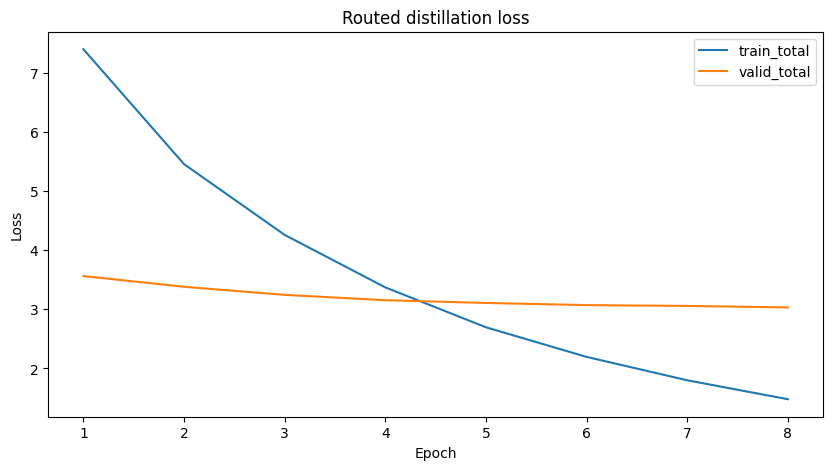

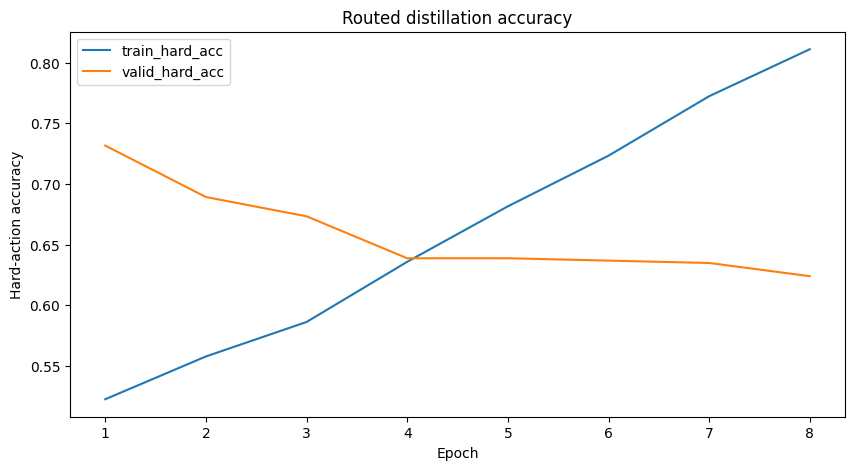

In [12]:

# Optional plots

import matplotlib.pyplot as plt

if len(train_history_df) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(train_history_df["epoch"], train_history_df["train_total"], label="train_total")
    plt.plot(train_history_df["epoch"], train_history_df["valid_total"], label="valid_total")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Routed distillation loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 5))
    plt.plot(train_history_df["epoch"], train_history_df["train_hard_acc"], label="train_hard_acc")
    plt.plot(train_history_df["epoch"], train_history_df["valid_hard_acc"], label="valid_hard_acc")
    plt.xlabel("Epoch")
    plt.ylabel("Hard-action accuracy")
    plt.title("Routed distillation accuracy")
    plt.legend()
    plt.show()


## Post-distillation evaluation and export

This final cell evaluates the distilled student on the full suite and saves:

- the distilled checkpoint
- the routed dataset workbook
- the training history workbook
- a JSON run summary

For V5, pay special attention to:

- whether `LA-2` finally moves off zero
- whether `LA-4 / LA-5 / LA-6` improve without sacrificing `LA-9 / LA-11 / LA-13`
- how many rows in the routed dataset came from `focus_adjudicated`


In [13]:
# ============================================================
# Final evaluation and export
# ============================================================

print("Evaluating distilled student...")
post_eval_df, post_eval_details = evaluate_model_on_suite(
    model=student_model,
    suite=DISTILL_EVAL_OPPONENTS,
    model_name=STUDENT_TAG,
    seed=SEED + 999,
    show_progress=True,
    tqdm_position=0,
    tqdm_leave=False,
)
display_eval(post_eval_df)

results_xlsx_path = OUTPUT_DIR / f"{STUDENT_TAG}_results.xlsx"
json_summary_path = OUTPUT_DIR / f"{STUDENT_TAG}_summary.json"
model_path = MODEL_DIR / f"{STUDENT_TAG}.pt"

if SAVE_MODEL_CHECKPOINT:
    save_cnet192(
        model=student_model.net,
        path=model_path,
        tag=STUDENT_TAG,
        session=STUDENT_TAG,
        episode=0,
        seed=SEED,
        t=0,
        cfg_override={"use_mid_3x3": bool(getattr(student_model.net, "use_mid_3x3", True))},
    )
    print("Saved distilled checkpoint to:", model_path)

if SAVE_RESULTS_XLSX:
    with pd.ExcelWriter(results_xlsx_path, engine="openpyxl") as writer:
        raw_states_df.to_excel(writer, sheet_name="raw_states", index=False)
        route_df.to_excel(writer, sheet_name="routes", index=False)
        route_type_counts_df.to_excel(writer, sheet_name="route_type_counts", index=False)
        captain_counts_df.to_excel(writer, sheet_name="captain_counts", index=False)
        source_pair_counts_df.to_excel(writer, sheet_name="source_pairs", index=False)
        route_source_pair_counts_df.to_excel(writer, sheet_name="route_source_pairs", index=False)
        unique_top_move_counts_df.to_excel(writer, sheet_name="unique_top_moves", index=False)
        hard_context_counts_df.to_excel(writer, sheet_name="hard_context_counts", index=False)
        focus_context_counts_df.to_excel(writer, sheet_name="focus_context_counts", index=False)
        if "adjudicator_disagreed" in route_df.columns:
            route_df.groupby(["adjudicator_disagreed", "route_type"]).size().reset_index(name="count").to_excel(writer, sheet_name="adj_disagree_counts", index=False)
        train_history_df.to_excel(writer, sheet_name="train_history", index=False)
        if pre_eval_df is not None:
            pre_eval_df.to_excel(writer, sheet_name="pre_eval", index=False)
        post_eval_df.to_excel(writer, sheet_name="post_eval", index=False)
    print("Saved results workbook to:", results_xlsx_path)

summary_payload = {
    "student_tag": STUDENT_TAG,
    "student_init": STUDENT_INIT,
    "anchor_model_path": ANCHOR_MODEL_PATH,
    "generalist_teachers": GENERALIST_TEACHERS,
    "specialist_teachers": SPECIALIST_TEACHERS,
    "teacher_prior_weights": {pretty_name(p): teacher_prior_weight(p) for p in ALL_TEACHERS},
    "match_plan": MATCH_PLAN,
    "routing_config": {
        "ROUTE_MIN_GENERALIST_AGREE_COUNT": ROUTE_MIN_GENERALIST_AGREE_COUNT,
        "ROUTE_MIN_GENERALIST_AGREE_SHARE": ROUTE_MIN_GENERALIST_AGREE_SHARE,
        "ROUTE_MIN_GENERALIST_VOTE_GAP": ROUTE_MIN_GENERALIST_VOTE_GAP,
        "ROUTE_MIN_AGREE_COUNT": ROUTE_MIN_AGREE_COUNT,
        "ROUTE_MIN_VOTE_SHARE": ROUTE_MIN_VOTE_SHARE,
        "ROUTE_MIN_WINNING_VOTE_GAP": ROUTE_MIN_WINNING_VOTE_GAP,
        "SPECIALIST_OVERRIDE_MIN_AGREE_COUNT": SPECIALIST_OVERRIDE_MIN_AGREE_COUNT,
        "SPECIALIST_OVERRIDE_MIN_SHARE": SPECIALIST_OVERRIDE_MIN_SHARE,
        "SPECIALIST_OVERRIDE_MARGIN_RATIO": SPECIALIST_OVERRIDE_MARGIN_RATIO,
        "USE_LOOKAHEAD_ADJUDICATOR": USE_LOOKAHEAD_ADJUDICATOR,
        "LOOKAHEAD_ADJUDICATOR_DEPTH": LOOKAHEAD_ADJUDICATOR_DEPTH,
        "LOOKAHEAD_ON_UNIQUE_TOP_MOVES_AT_LEAST": LOOKAHEAD_ON_UNIQUE_TOP_MOVES_AT_LEAST,
        "LOOKAHEAD_ON_BEST_VOTE_SHARE_BELOW": LOOKAHEAD_ON_BEST_VOTE_SHARE_BELOW,
        "LOOKAHEAD_ON_HARD_CONTEXT_ALWAYS": LOOKAHEAD_ON_HARD_CONTEXT_ALWAYS,
        "HARD_CONTEXT_MIN_PLY": HARD_CONTEXT_MIN_PLY,
        "HARD_CONTEXT_MIN_UNIQUE_TOP_MOVES": HARD_CONTEXT_MIN_UNIQUE_TOP_MOVES,
        "HARD_CONTEXT_LOW_SHARE_BELOW": HARD_CONTEXT_LOW_SHARE_BELOW,
        "HARD_CONTEXT_LOW_GAP_BELOW": HARD_CONTEXT_LOW_GAP_BELOW,
        "SOFT_TARGET_POWER": SOFT_TARGET_POWER,
        "FOCUS_OPPONENT_LABELS": sorted(FOCUS_OPPONENT_LABELS),
        "DEEP_PRESERVE_OPPONENT_LABELS": sorted(DEEP_PRESERVE_OPPONENT_LABELS),
        "FOCUS_CONTEXT_MIN_PLY": FOCUS_CONTEXT_MIN_PLY,
        "FOCUS_CONTEXT_LOW_SHARE_BELOW": FOCUS_CONTEXT_LOW_SHARE_BELOW,
        "FOCUS_CONTEXT_LOW_GAP_BELOW": FOCUS_CONTEXT_LOW_GAP_BELOW,
        "LOOKAHEAD_ON_FOCUS_CONTEXT_ALWAYS": LOOKAHEAD_ON_FOCUS_CONTEXT_ALWAYS,
        "FOCUS_ADJUDICATOR_DEPTH_BY_LABEL": dict(FOCUS_ADJUDICATOR_DEPTH_BY_LABEL),
        "FOCUS_ROUTE_MIN_PLY": FOCUS_ROUTE_MIN_PLY,
        "FOCUS_ROUTE_MAX_PLY": FOCUS_ROUTE_MAX_PLY,
        "FOCUS_EASY_KEEP_EVERY_N": FOCUS_EASY_KEEP_EVERY_N,
    },
    "training_config": {
        "LOSS_W_SOFT": LOSS_W_SOFT,
        "LOSS_W_HARD": LOSS_W_HARD,
        "LOSS_W_VALUE": LOSS_W_VALUE,
        "ANCHOR_LOSS_WEIGHT": ANCHOR_LOSS_WEIGHT,
        "ANCHOR_HARD_CONTEXT_MULT": ANCHOR_HARD_CONTEXT_MULT,
        "ANCHOR_SPECIAL_ROUTE_MULT": ANCHOR_SPECIAL_ROUTE_MULT,
        "ANCHOR_FOCUS_CONTEXT_MULT": ANCHOR_FOCUS_CONTEXT_MULT,
        "DEEP_PRESERVE_ANCHOR_MULT": DEEP_PRESERVE_ANCHOR_MULT,
        "KEEP_BEST_BY": KEEP_BEST_BY,
        "EVAL_EVERY_EPOCHS": EVAL_EVERY_EPOCHS,
        "MINI_EVAL_OPPONENTS": MINI_EVAL_OPPONENTS,
    },
    "dataset": {
        "n_raw_states": int(len(raw_states_df)),
        "n_routed_states": int(len(routed_dataset["hard_actions"])),
        "route_type_counts": route_type_counts_df.to_dict(orient="records"),
        "captain_counts": captain_counts_df.to_dict(orient="records"),
        "unique_top_move_counts": unique_top_move_counts_df.to_dict(orient="records"),
        "hard_context_counts": hard_context_counts_df.to_dict(orient="records"),
        "focus_context_counts": focus_context_counts_df.to_dict(orient="records"),
    },
    "training": {
        "epochs_configured": EPOCHS,
        "best_epoch": int(train_info["best_epoch"]),
        "best_score": float(train_info["best_score"]),
        "keep_best_by": train_info["keep_best_by"],
        "history": train_history_df.to_dict(orient="records"),
    },
    "pre_eval": None if pre_eval_df is None else pre_eval_df.iloc[0].to_dict(),
    "post_eval": post_eval_df.iloc[0].to_dict(),
}

if SAVE_JSON_SUMMARY:
    json_summary_path.write_text(json.dumps(summary_payload, indent=2, default=str), encoding="utf-8")
    print("Saved JSON summary to:", json_summary_path)

print("\nArtifacts:")
print("  dataset_pkl:", dataset_path)
print("  route_summary_xlsx:", route_summary_path)
print("  results_xlsx:", results_xlsx_path)
print("  model_checkpoint:", model_path)
print("  json_summary:", json_summary_path)


Evaluating distilled student...


Evaluating ROUTED_DISTILL_S4_V5:   0%|          | 0/13 [00:00<?, ?it/s]

,MODEL,Random,Leftmost,Center,LA-1,LA-2,LA-3,LA-4,LA-5,LA-6,LA-7,LA-9,LA-11,LA-13,AVG_SCORE,LA_HARD,GS_CUSTOM
0,ROUTED_DISTILL_S4_V5,1.000,1.000,1.000,1.000,0.000,1.000,1.000,0.500,0.500,0.500,0.500,0.500,0.500,0.692,0.571,0.526


Metric [GS_CUSTOM] = 0.5255071556238894
Saved distilled checkpoint to: PPO_Models\ROUTED_DISTILL_S4_V5.pt
Saved results workbook to: DISTILL\ROUTED_DISTILL_S4_V5_results.xlsx
Saved JSON summary to: DISTILL\ROUTED_DISTILL_S4_V5_summary.json

Artifacts:
  dataset_pkl: DISTILL\data\ROUTED_DISTILL_S4_V5_routed_dataset.pkl
  route_summary_xlsx: DISTILL\data\ROUTED_DISTILL_S4_V5_route_summary.xlsx
  results_xlsx: DISTILL\ROUTED_DISTILL_S4_V5_results.xlsx
  model_checkpoint: PPO_Models\ROUTED_DISTILL_S4_V5.pt
  json_summary: DISTILL\ROUTED_DISTILL_S4_V5_summary.json



## What changed in V4, and what to inspect first

V4 keeps the stable backbone-preserving ideas from V3, but narrows the mission.

Inspect these things first after a run:

1. **focus-context rate**. It should be materially larger on `LA-2 / 4 / 5 / 6` source games, without swallowing the whole dataset.
2. **route mix on focus contexts**. You want some adjudication and a little specialist help, but still a generalist-first world.
3. **mini_eval_FOCUS_PRESERVE through epochs**. This is the main checkpoint-selection signal in V4.
4. **post-run tradeoff between `LA-4/5/6` and deep scores `LA-9/11/13`**. V4 should improve the remaining holes without amputating the deep structure.

If V4 is still flat, the next step is usually not broader routing, but sharper failure mining from specific losing games.
